In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from region import Region
from functions import Functions
pfns = PlottingFns()
fns = Functions()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
from cartopy.feature import LAND
from gsw import conversions, density
from glob import glob


In [4]:
f140 = '../data/SOSE/Adelie_140E_*.nc'
f145 = '../data/SOSE/Adelie_145E_*.nc'
fseg = '../data/SOSE/Adelie_138E_150E/Adelie*.nc'

In [5]:
ds140 = xr.open_mfdataset(glob(f140))
ds145 = xr.open_mfdataset(glob(f145))

In [6]:
dsseg = xr.open_mfdataset(glob(fseg))

In [7]:
gyre_index = xr.open_dataarray('gyre_index.nc')
ssh_index = xr.open_dataarray('ssh_index.nc')
sla_ = SLA(deg=0.25).da
winds_ = xr.open_dataset('../data/ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})


In [8]:
asc = xr.open_dataarray('asc_index.nc')

In [9]:
minla = -68
maxla = -63

extent_ac = [138,152,minla,maxla]
extent_ea=[60,160,-70,-60]

region_ac = Region('AC',extent_ac)
sla = region_ac.crop_da(sla_)
winds = region_ac.crop_da(winds_)

# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

u,v = fns.get_geostrophic_currents(sla)
geos = xr.Dataset({'u10':u,'v10':v})

In [10]:
# chop and resample SOSE
ds145 = ds145.sel(YC = slice(minla,maxla)).sel(YG = slice(minla-0.03,maxla-0.03))
ds140 = ds140.sel(YC = slice(minla,maxla)).sel(YG = slice(minla-0.03,maxla-0.03))

ds145 = ds145.resample({'time':'MS'}).mean()
ds140 = ds140.resample({'time':'MS'}).mean()
dsseg = dsseg.resample({'time':'MS'}).mean()

In [11]:
ds145.load()
ds140.load()
dsseg.load()

<xarray.Dataset> Size: 152MB
Dimensions:  (time: 132, YC: 15, XC: 72, XG: 73, YG: 14, Z: 52, Zl: 52, Zu: 52,
              Zp1: 53)
Coordinates: (12/22)
  * time     (time) datetime64[ns] 1kB 2013-01-01 2013-02-01 ... 2023-12-01
  * YC       (YC) float64 120B -65.97 -65.91 -65.84 ... -65.15 -65.08 -65.01
  * XC       (XC) float64 576B 138.1 138.2 138.4 138.6 ... 149.6 149.8 149.9
    dyC      (YG, XC) float64 8kB 7.555e+03 7.555e+03 ... 7.819e+03 7.819e+03
    dxG      (YG, XC) float64 8kB 7.555e+03 7.555e+03 ... 7.819e+03 7.819e+03
    rA       (YC, XC) float64 9kB 5.692e+07 5.692e+07 ... 6.13e+07 6.13e+07
    ...       ...
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
    drF      (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
  * Zl       (Zl) float64 416B 0.0 -4.2 -9.2 ... -4.8e+03 -5.2e+03 -5.6e+03
  * Zu       (Zu) int64 416B 0 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50 51
  * Zp1      (Zp1) float64 424B 0.0 -4.2 -9.2 -15.1 ... -5.2e+03 -5.6e+03 -6e+03
    drC      (Zp1) float64 424B 2.1 4.6 5.45 6.4 7.7 ... 400.0 400.0 400.0 200.0
Data variables:
    ETAN     (time, YC, XC) float32 570kB -2.594 -2.581 -2.568 ... -1.639 -1.642
    SIarea   (time, YC, XC) float32 570kB 0.9754 0.9739 0.9719 ... 0.5276 0.5225
    SIheff   (time, YC, XC) float32 570kB 1.039 1.024 1.01 ... 0.2141 0.2079
    SIuice   (time, YC, XG) float32 578kB -0.284 -0.2833 ... 0.2155 0.1625
    SIvice   (time, YG, XC) float32 532kB 0.04439 0.04574 ... 0.1308 0.09934
    SIhsnow  (time, YC, XC) float32 570kB 0.2433 0.2428 ... 0.07917 0.0767
    BLGMLD   (time, YC, XC) float32 570kB 33.59 39.2 40.17 ... 37.29 29.48 26.28
    THETA    (time, Z, YC, XC) float32 30MB -1.841 -1.837 -1.832 ... 0.0 0.0 0.0
    SALT     (time, Z, YC, XC) float32 30MB 33.81 33.8 33.79 ... 0.0 0.0 0.0
    UVEL     (time, Z, YC, XG) float32 30MB -0.1135 -0.1136 -0.113 ... 0.0 0.0
    VVEL     (time, Z, YG, XC) float32 28MB -0.01574 -0.01788 ... 0.0 0.0
    WVEL     (time, Zl, YC, XC) float32 30MB -5.79e-08 -5.579e-08 ... 0.0 0.0

In [12]:
ds145['SALT'] = ds145.SALT.where(ds145.SALT > 30)
ds145['THETA'] = ds145.THETA.where(~(ds145.THETA==0),np.nan)

In [13]:
# compute density etc
def calc_vars(ds):
    ds['pressure'] = conversions.p_from_z(ds.Z,ds.YC.mean())
    ds['asal'] = conversions.SA_from_SP(ds.SALT,ds.pressure,145,ds.YC).where(-ds.Z < ds.Depth,drop=True)
    ds['ctemp'] = conversions.CT_from_t(ds.asal,ds.THETA,ds.pressure).where(-ds.Z < ds.Depth,drop=True)
    ds['rho'] = density.rho(ds.asal,ds.ctemp,ds.pressure)
    ds['sigma0'] = density.sigma0(ds.asal,ds.ctemp)

calc_vars(ds145)
calc_vars(ds140)
calc_vars(dsseg)

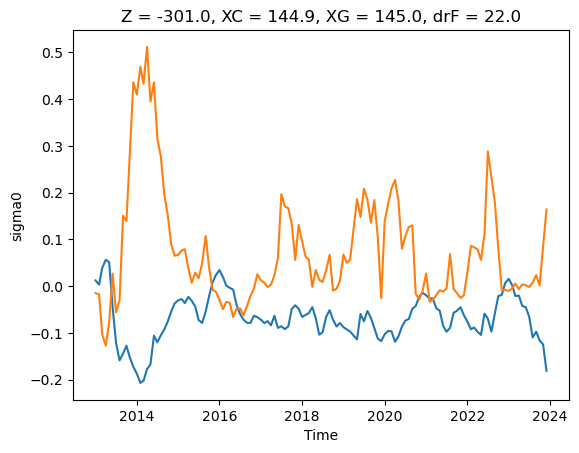

In [14]:
sigshelf = ds145.sigma0.sel(YC=-66.7,method='nearest').sel(Z=-300,method='nearest')
sigocean = ds145.sigma0.sel(YC=-65.5,method='nearest').sel(Z=-300,method='nearest')
sigdiff = sigshelf - sigocean
sigdiff.plot()

sigdiff2 = ds145.sigma0.differentiate('YC').sel(YC=slice(-65.9,-65.6)).sel(Z=-300,method='nearest').max('YC')
sigdiff2.plot()

In [15]:
sigdiff2.to_netcdf('sigdiff2.nc')

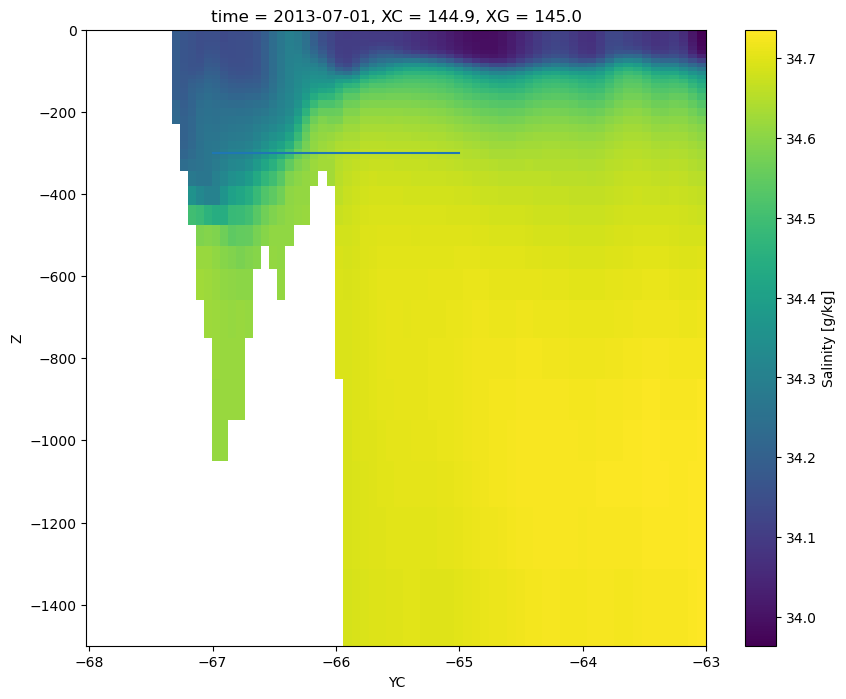

In [16]:
fig, ax = plt.subplots(figsize=(10,8))
ds145.SALT.isel(time=6).plot(ax=ax)
ax.set_ylim([-1500,0])
ax.plot([-67,-65],[-300,-300])

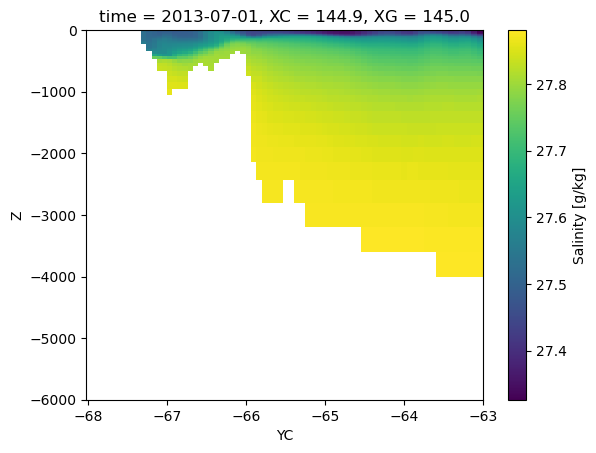

In [17]:
ds145.isel(time=6).sigma0.plot()

In [18]:
t1 = ds145.time[0]
t2 = sla.time[-1]

In [19]:
# prepare other data
sa_sla = fns.seasonal_anomaly(sla.sel(time=slice(t1,t2)))
sa_winds = fns.seasonal_anomaly(winds.sel(time=slice(t1,t2)))
sa_geos = fns.seasonal_anomaly(geos.sel(time=slice(t1,t2)))
sa_gyre = fns.seasonal_anomaly(gyre_index.sel(time=slice(t1,t2)))
sa_asc = fns.seasonal_anomaly(asc.sel(time=slice(t1,t2)))
sa_sose_145 = fns.seasonal_anomaly(ds145)
sa_sose_140 = fns.seasonal_anomaly(ds140)
sa_sose_seg = fns.seasonal_anomaly(dsseg)
sa_ssh = fns.seasonal_anomaly(ssh_index)


ssn_gyre = fns.season_split(sa_gyre)
ssn_sla = fns.season_split(sa_sla)
ssn_geos = fns.season_split(sa_geos)
ssn_sose_145 = fns.season_split(sa_sose_145)
ssn_sose_140 = fns.season_split(sa_sose_140)
ssn_sose_seg = fns.season_split(sa_sose_seg)
ssn_asc = fns.season_split(sa_asc)


In [20]:

from datetime import datetime
from dateutil.relativedelta import relativedelta as rd


In [25]:
def plot_transect(data,ax,title,text,vmin,vmax):
    im=data.plot.contourf(ax=ax,vmin=vmin,vmax=vmax,cmap=cmocean.cm.balance,add_colorbar=False,levels=40)
    ax.set_title(title,loc='left')
    ax.set_ylim([-1500,0])
    ax.set_xlim([-67.5,-64.5])
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Depth (m)')
    ax.text(-67.35,-1400,text,fontweight='bold')
    ax.set_title(None)
    return im


In [22]:
ssns = fns.season_split(ds145)

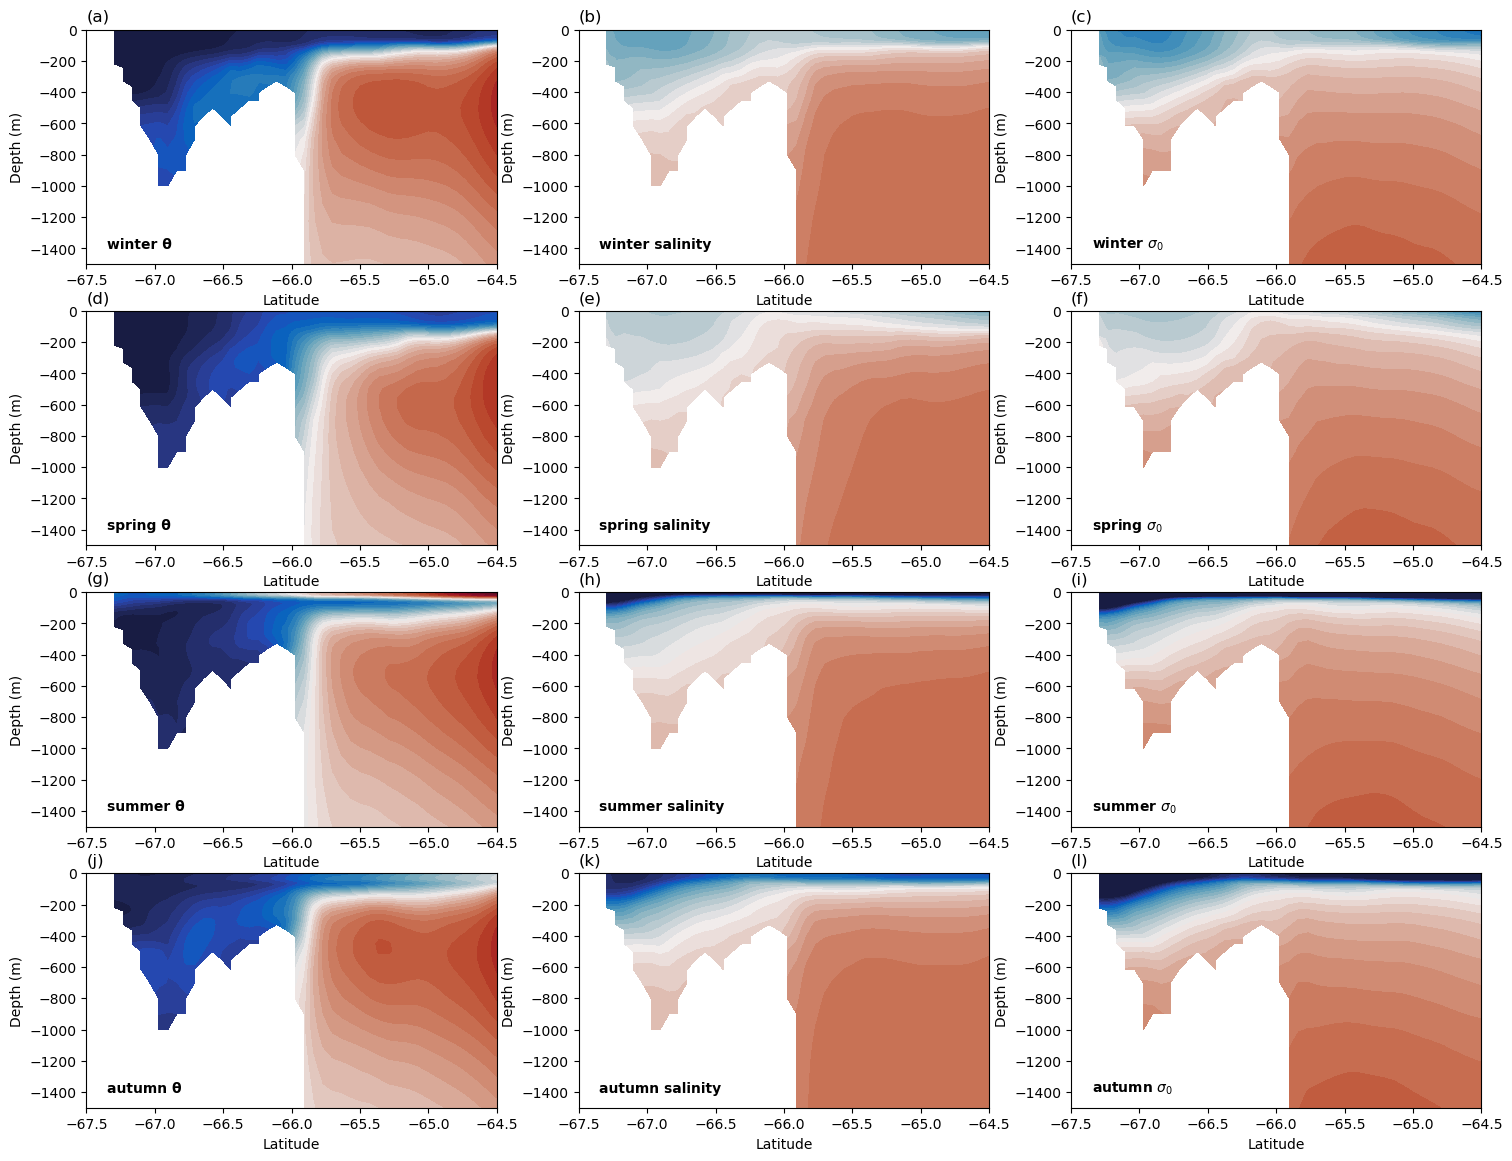

In [29]:
fig,axs = plt.subplots(4,3,figsize=(18,14))

labels=[['(a)','(b)','(c)'],['(d)','(e)','(f)'],['(g)','(h)','(i)'],['(j)','(k)','(l)']]
for ssn,ax,l in zip(ssns,axs,labels):
    plot_transect(ssns[ssn].THETA.mean('time'),ax[0],l[0],'{} θ'.format(ssn),-1.5,1.5)
    plot_transect(ssns[ssn].SALT.mean('time'),ax[1],l[1],'{} salinity'.format(ssn),34,35)
    plot_transect(ssns[ssn].sigma0.mean('time'),ax[2],l[2],'{} $σ_0$ '.format(ssn), 27.5, 28)


/tmp/ipykernel_154877/4043010604.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


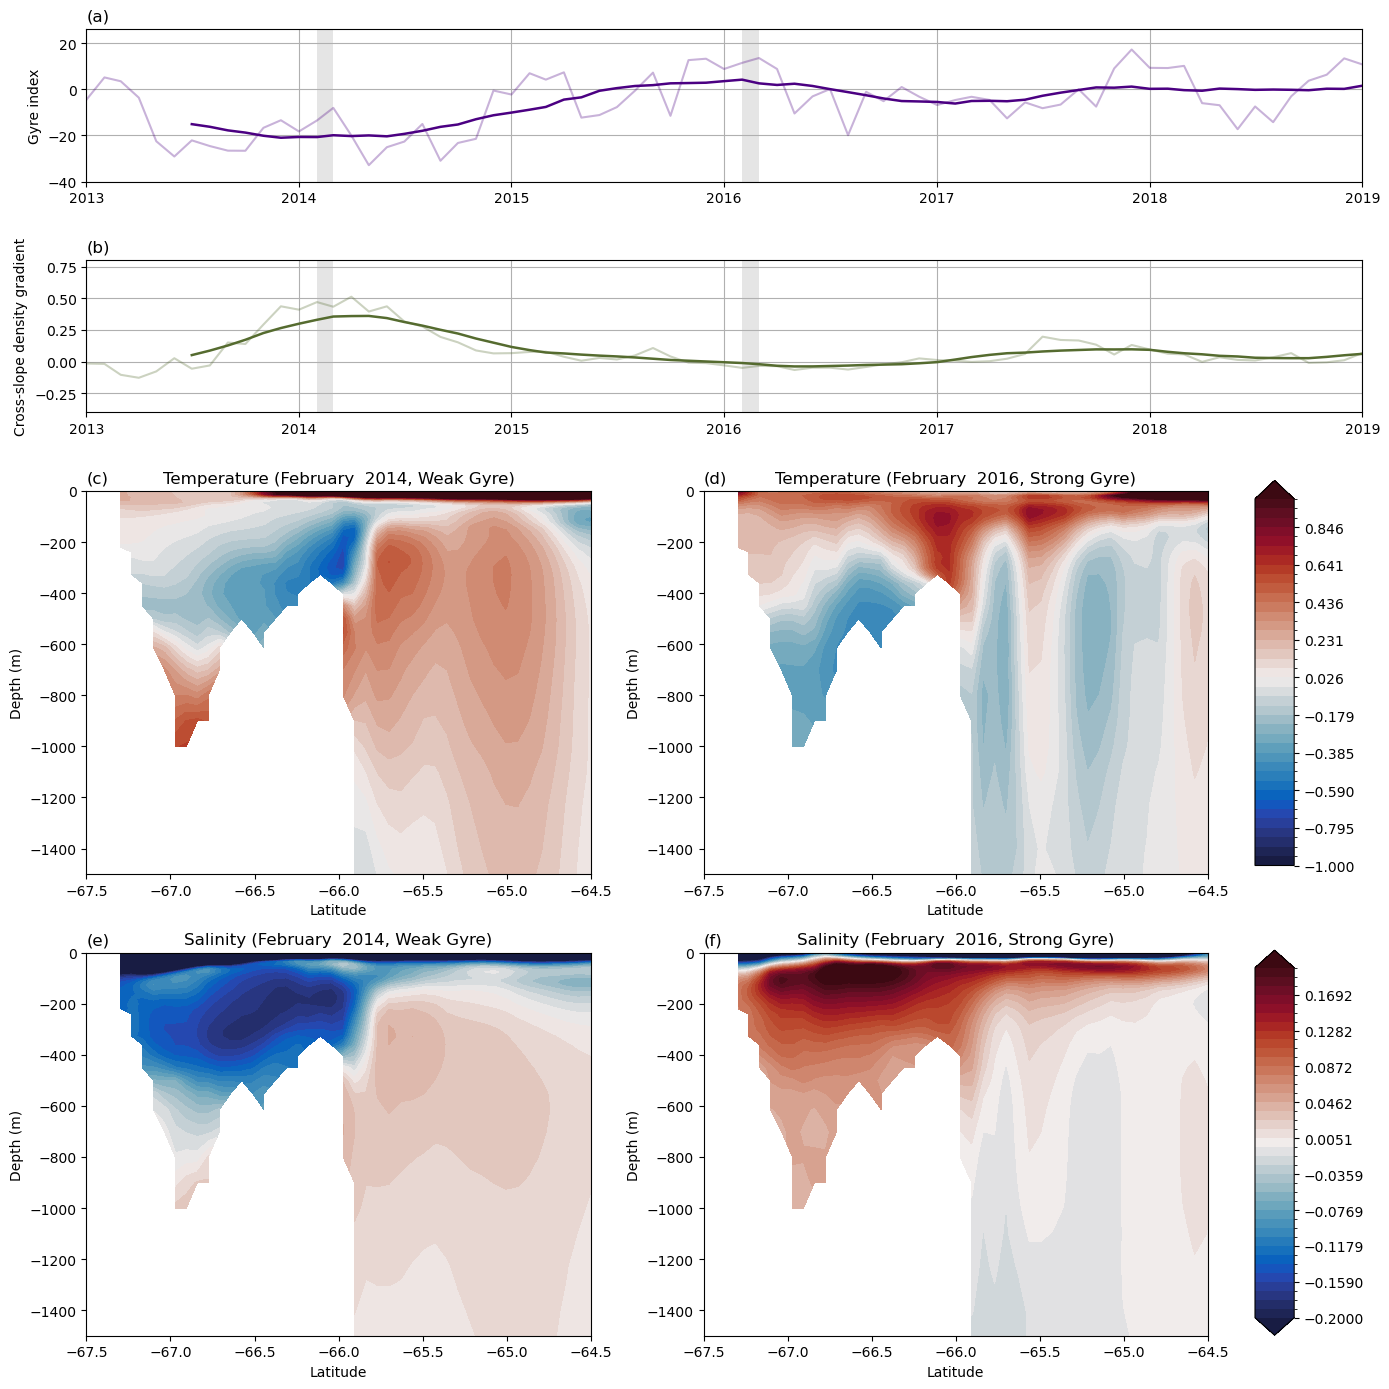

In [24]:
m=12
lag=2
t1 = pd.Timestamp(2013,m,1)
t2 = pd.Timestamp(2015,m,1)

txt='February '
ltxt = ' (' + txt + ' 2014, Weak Gyre)'
rtxt = ' (' + txt + ' 2016, Strong Gyre)'

def getdt(var):
    ts = utls.detrend_dim(ds145[var],'time')
    return ts.sel(time = t1+rd(months=lag),method='nearest'), ts.sel(time = t2+rd(months=lag),method='nearest')


fig = plt.figure(figsize=(14,14))
gs = fig.add_gridspec(6,9)

ax = fig.add_subplot(gs[0, :])
git = gyre_index.sel(time=slice(pd.Timestamp(2013,1,1),pd.Timestamp(2024,1,1)))
ax.plot(git.time,git,c='indigo',alpha=0.3)
ax.plot(git.time,git.rolling({'time':12},center=True).mean(),c='indigo',linewidth=1.8)
for t in [t1,t2]:
    t1a = t + rd(months=lag)
    t2a = t + rd(months=lag+1)
    tboo = (git.time >= t1a) & (git.time <= t2a)
    
    ax.fill_between(git.time, -100,100, where=tboo, alpha=0.2, facecolor='grey',label='lalala')
ax.grid()
ax.set_ylim([-40,26])
ax.set_ylabel('Gyre index')
ax.set_xlim([ds145.time[0],pd.Timestamp(2019,1,1)])
ax.set_title('(a)',loc='left')

ax = fig.add_subplot(gs[1,:])
sdt = sigdiff2.sel(time=slice(pd.Timestamp(2013,1,1),pd.Timestamp(2024,1,1)))
ax.plot(sdt.time,sdt,c='darkolivegreen',alpha=0.3)
ax.plot(sdt.time,sdt.rolling({'time':12},center=True).mean(),c='darkolivegreen',linewidth=1.8)

ax.grid()
for t in [t1,t2]:
    t1a = t + rd(months=lag)
    t2a = t + rd(months=lag+1)
    tboo = (sdt.time >= t1a) & (sdt.time <= t2a)
    
    ax.fill_between(sdt.time, -10,10, where=tboo, alpha=0.2, facecolor='grey',label='lalala')
ax.set_ylim([-0.4,0.8])
ax.set_ylabel('Cross-slope density gradient')
ax.set_xlim([ds145.time[0],pd.Timestamp(2019,1,1)])
ax.set_title('(b)',loc='left')


ax1=fig.add_subplot(gs[2:4,0:4])
ax2=fig.add_subplot(gs[2:4,4:8])

tp,bt = getdt('THETA')
plot_transect(tp,ax1,'Temperature' + ltxt,-1,1)#-1.5,1.5)
im=plot_transect(bt,ax2,'Temperature'+rtxt,-1,1)#.5,1.5)
cbar_ax = fig.add_axes([0.9, 0.3775, 0.028, 0.275])
fig.colorbar(im, cax=cbar_ax)
ax1.set_title('(c)',loc='left')
ax2.set_title('(d)',loc='left')

ax1=fig.add_subplot(gs[4:6,0:4])
ax2=fig.add_subplot(gs[4:6,4:8])
# ax3=fig.add_subplot(gs[4:6,8:12])

tp,bt = getdt('SALT')
plot_transect(tp,ax1,'Salinity' +ltxt,-0.2,0.2)#34.2,34.8)
im=plot_transect(bt,ax2,'Salinity'+rtxt,-0.2,0.2)#34.2,34.8)

#fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.9, 0.042, 0.028, 0.275])
fig.colorbar(im, cax=cbar_ax)
ax1.set_title('(e)',loc='left')
ax2.set_title('(f)',loc='left')

plt.tight_layout()


In [25]:
dotds = DOT(ver='egm').ds.rename({'ug':'u10','vg':'v10'})
lwe_ds = GRACE().ds
sha_ds_sla = StericHeight(ssh_ref='DOT',
                      ssh=dotds.dot,#sla_,#SLA(deg=1).da,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha().sel(longitude=145,method='nearest').sel(latitude=slice(-67.5,-64.5)).mean('latitude')

/tmp/ipykernel_154877/1773152149.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


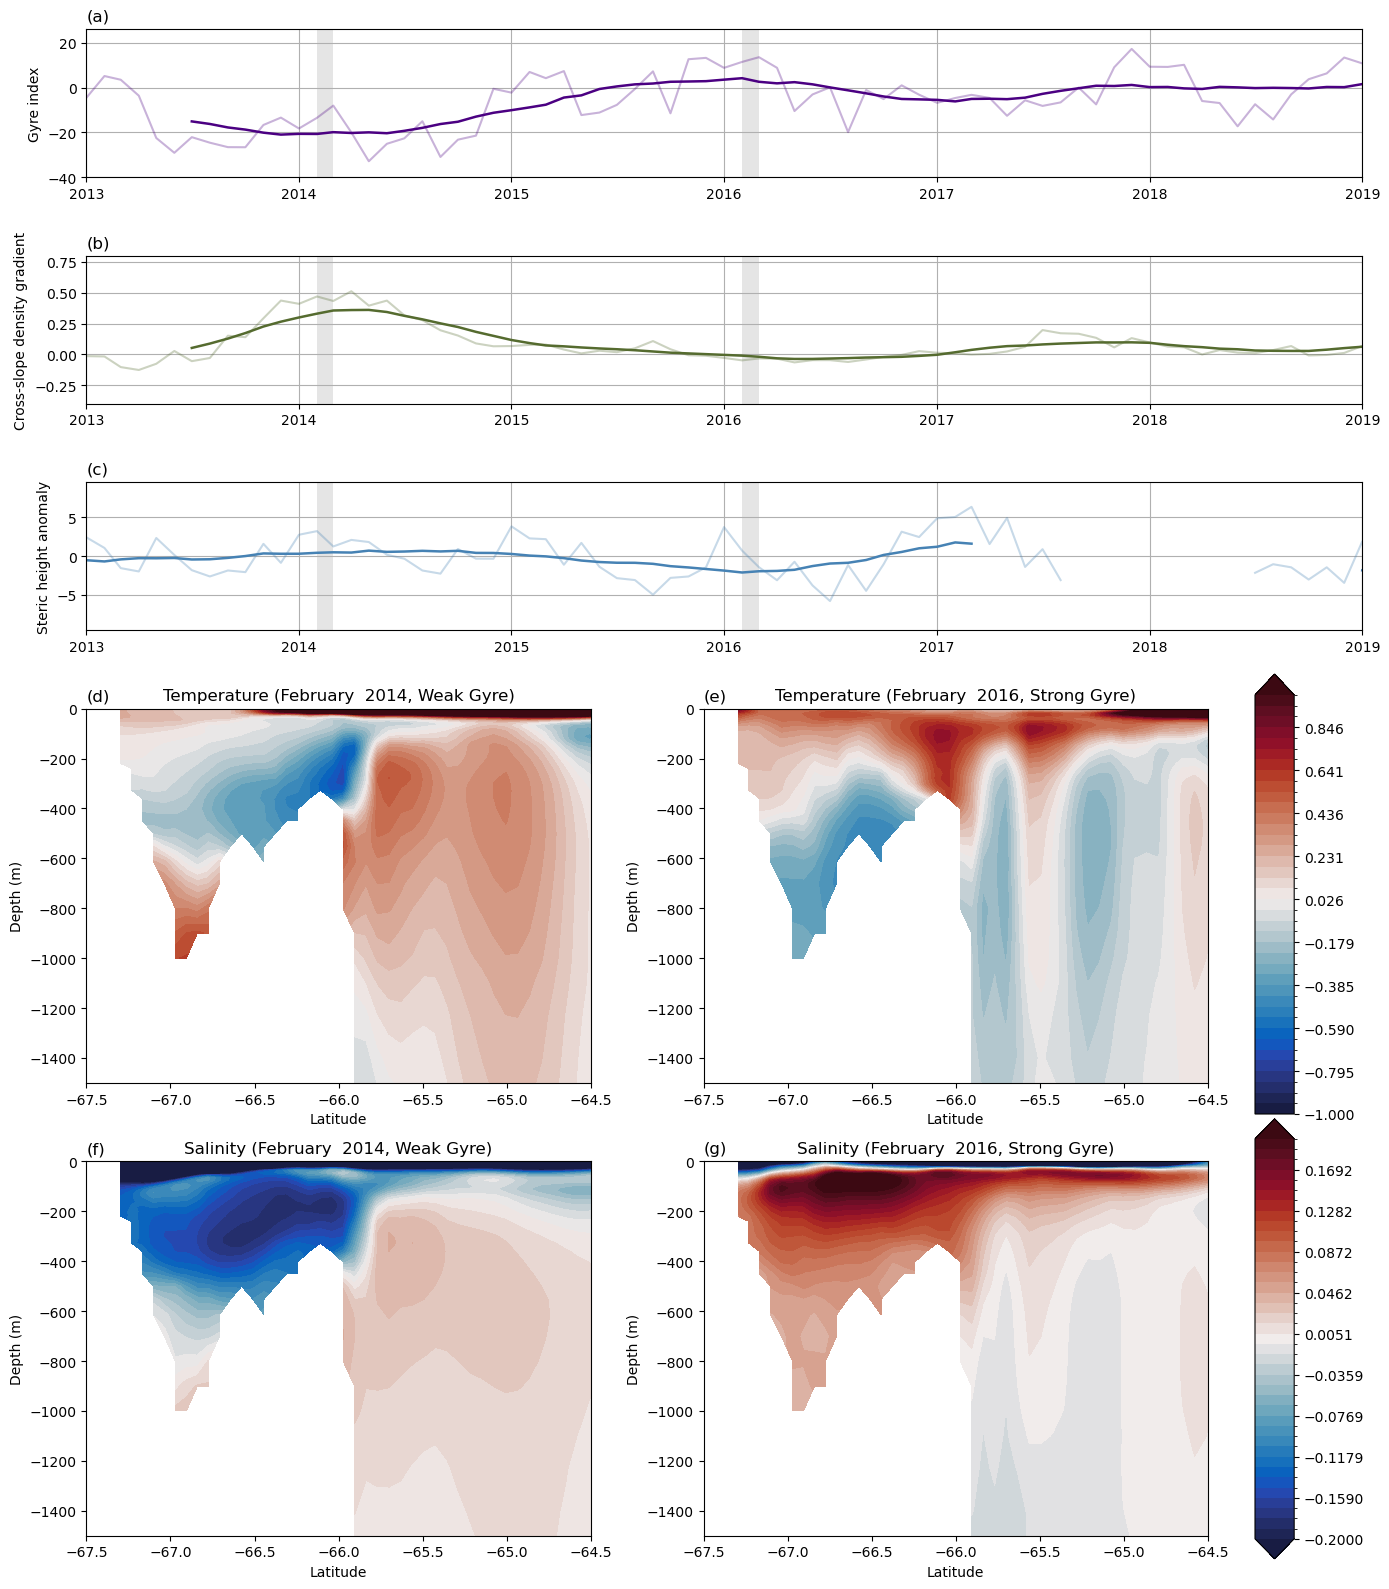

In [32]:
m=12
lag=2
t1 = pd.Timestamp(2013,m,1)
t2 = pd.Timestamp(2015,m,1)

txt='February '
ltxt = ' (' + txt + ' 2014, Weak Gyre)'
rtxt = ' (' + txt + ' 2016, Strong Gyre)'

def getdt(var):
    ts = utls.detrend_dim(ds145[var],'time')
    return ts.sel(time = t1+rd(months=lag),method='nearest'), ts.sel(time = t2+rd(months=lag),method='nearest')


fig = plt.figure(figsize=(14,16))
gs = fig.add_gridspec(7,9)

ax = fig.add_subplot(gs[0, :])
git = gyre_index.sel(time=slice(pd.Timestamp(2013,1,1),pd.Timestamp(2024,1,1)))
ax.plot(git.time,git,c='indigo',alpha=0.3)
ax.plot(git.time,git.rolling({'time':12},center=True).mean(),c='indigo',linewidth=1.8)
for t in [t1,t2]:
    t1a = t + rd(months=lag)
    t2a = t + rd(months=lag+1)
    tboo = (git.time >= t1a) & (git.time <= t2a)
    
    ax.fill_between(git.time, -100,100, where=tboo, alpha=0.2, facecolor='grey',label='lalala')
ax.grid()
ax.set_ylim([-40,26])
ax.set_ylabel('Gyre index')
ax.set_xlim([ds145.time[0],pd.Timestamp(2019,1,1)])
ax.set_title('(a)',loc='left')

ax = fig.add_subplot(gs[1,:])
sdt = sigdiff2.sel(time=slice(pd.Timestamp(2013,1,1),pd.Timestamp(2024,1,1)))
ax.plot(sdt.time,sdt,c='darkolivegreen',alpha=0.3)
ax.plot(sdt.time,sdt.rolling({'time':12},center=True).mean(),c='darkolivegreen',linewidth=1.8)

ax.grid()
for t in [t1,t2]:
    t1a = t + rd(months=lag)
    t2a = t + rd(months=lag+1)
    tboo = (sdt.time >= t1a) & (sdt.time <= t2a)
    
    ax.fill_between(sdt.time, -10,10, where=tboo, alpha=0.2, facecolor='grey',label='lalala')
ax.set_ylim([-0.4,0.8])
ax.set_ylabel('Cross-slope density gradient')
ax.set_xlim([ds145.time[0],pd.Timestamp(2019,1,1)])
ax.set_title('(b)',loc='left')

ax = fig.add_subplot(gs[2,:])
sdt = sha_ds_sla.sha
ax.plot(sdt.time,sdt,c='steelblue',alpha=0.3)
ax.plot(sdt.time,sdt.rolling({'time':12},center=True).mean(),c='steelblue',linewidth=1.8)

ax.grid()
for t in [t1,t2]:
    t1a = t + rd(months=lag)
    t2a = t + rd(months=lag+1)
    tboo = (sdt.time >= t1a) & (sdt.time <= t2a)
    
    ax.fill_between(sdt.time, -10,10, where=tboo, alpha=0.2, facecolor='grey',label='lalala')
ax.set_ylim([-9.5,9.5])

ax.set_ylabel('Steric height anomaly')
ax.set_xlim([ds145.time[0],pd.Timestamp(2019,1,1)])
ax.set_title('(c)',loc='left')



ax1=fig.add_subplot(gs[3:5,0:4])
ax2=fig.add_subplot(gs[3:5,4:8])


tp,bt = getdt('THETA')
plot_transect(tp,ax1,'Temperature' + ltxt,-1,1)#-1.5,1.5)
im=plot_transect(bt,ax2,'Temperature'+rtxt,-1,1)#.5,1.5)
cbar_ax = fig.add_axes([0.9, 0.3, 0.028, 0.275])
fig.colorbar(im, cax=cbar_ax)
ax1.set_title('(d)',loc='left')
ax2.set_title('(e)',loc='left')

ax1=fig.add_subplot(gs[5:7,0:4])
ax2=fig.add_subplot(gs[5:7,4:8])
# ax3=fig.add_subplot(gs[4:6,8:12])

tp,bt = getdt('SALT')
plot_transect(tp,ax1,'Salinity' +ltxt,-0.2,0.2)#34.2,34.8)
im=plot_transect(bt,ax2,'Salinity'+rtxt,-0.2,0.2)#34.2,34.8)

#fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.9, 0.022, 0.028, 0.275])
fig.colorbar(im, cax=cbar_ax)
ax1.set_title('(f)',loc='left')
ax2.set_title('(g)',loc='left')

plt.tight_layout()


/tmp/ipykernel_154877/2678834235.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


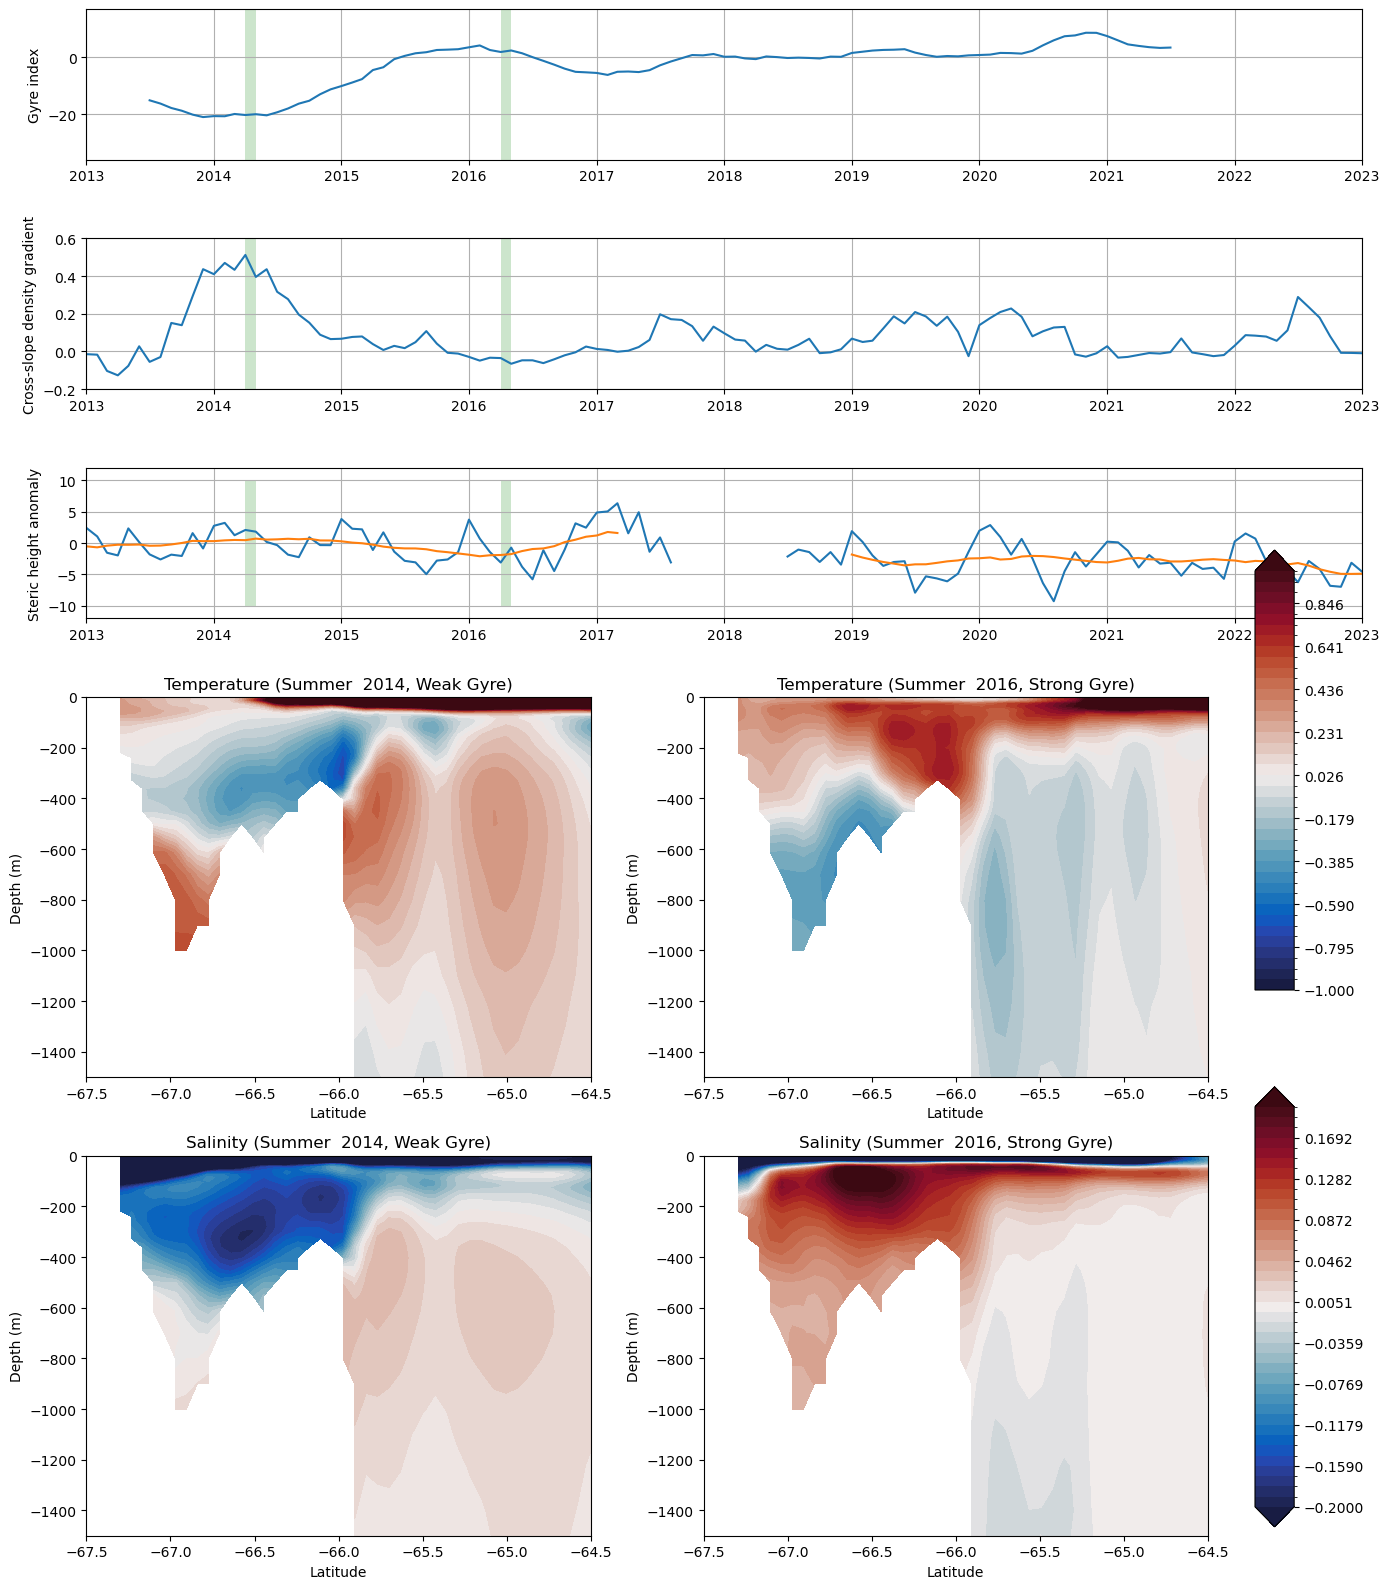

In [27]:
m=10
lag=5
t1 = pd.Timestamp(2013,m,1)
t2 = pd.Timestamp(2015,m,1)

txt='Summer '
ltxt = ' (' + txt + ' 2014, Weak Gyre)'
rtxt = ' (' + txt + ' 2016, Strong Gyre)'

def getdt(var):
    ts = utls.detrend_dim(ds145[var],'time')
    return ts.sel(time = t1+rd(months=lag),method='nearest'), ts.sel(time = t2+rd(months=lag),method='nearest')


fig = plt.figure(figsize=(14,16))
gs = fig.add_gridspec(7,9)

ax = fig.add_subplot(gs[0, :])
git = gyre_index.sel(time=slice(pd.Timestamp(2013,1,1),pd.Timestamp(2024,1,1)))
ax.plot(git.time,git.rolling({'time':12},center=True).mean())
for t in [t1,t2]:
    t1a = t + rd(months=lag)
    t2a = t + rd(months=lag+3)
    tboo = (git.time > t1a) & (git.time < t2a)
    
    ax.fill_between(git.time, -100,100, where=tboo, alpha=0.2, facecolor='green',label='lalala')
ax.grid()
ax.set_ylim([-36,17])
ax.set_ylabel('Gyre index')
ax.set_xlim([pd.Timestamp(2013,1,1),pd.Timestamp(2023,1,1)])

ax = fig.add_subplot(gs[1,:])
sdt = sigdiff2.sel(time=slice(pd.Timestamp(2013,1,1),pd.Timestamp(2024,1,1)))
ax.plot(sdt.time,sdt)
ax.grid()
for t in [t1,t2]:
    t1a = t + rd(months=lag)
    t2a = t + rd(months=lag+3)
    tboo = (sdt.time > t1a) & (sdt.time < t2a)
    
    ax.fill_between(sdt.time, -10,10, where=tboo, alpha=0.2, facecolor='green',label='lalala')
ax.set_ylim([-0.2,0.6])
ax.set_ylabel('Cross-slope density gradient')
ax.set_xlim([pd.Timestamp(2013,1,1),pd.Timestamp(2023,1,1)])


ax = fig.add_subplot(gs[2,:])
sdt = sha_ds_sla.sha
ax.plot(sdt.time,sdt)
ax.plot(sdt.time,sdt.rolling({'time':12},center=True).mean())

ax.grid()
for t in [t1,t2]:
    t1a = t + rd(months=lag)
    t2a = t + rd(months=lag+3)
    tboo = (sdt.time > t1a) & (sdt.time < t2a)
    
    ax.fill_between(sdt.time, -10,10, where=tboo, alpha=0.2, facecolor='green',label='lalala')
ax.set_ylim([-12,12])

ax.set_ylabel('Steric height anomaly')
ax.set_xlim([pd.Timestamp(2013,1,1),pd.Timestamp(2023,1,1)])



ax1=fig.add_subplot(gs[3:5,0:4])
ax2=fig.add_subplot(gs[3:5,4:8])

tp,bt = getdt('THETA')
plot_transect(tp,ax1,'Temperature' + ltxt,-1,1)#-1.5,1.5)
im=plot_transect(bt,ax2,'Temperature'+rtxt,-1,1)#.5,1.5)
cbar_ax = fig.add_axes([0.9, 0.3775, 0.028, 0.275])
fig.colorbar(im, cax=cbar_ax)

ax1=fig.add_subplot(gs[5:7,0:4])
ax2=fig.add_subplot(gs[5:7,4:8])
# ax3=fig.add_subplot(gs[4:6,8:12])

tp,bt = getdt('SALT')
plot_transect(tp,ax1,'Salinity' +ltxt,-0.2,0.2)#34.2,34.8)
im=plot_transect(bt,ax2,'Salinity'+rtxt,-0.2,0.2)#34.2,34.8)

#fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.9, 0.042, 0.028, 0.275])
fig.colorbar(im, cax=cbar_ax)

plt.tight_layout()


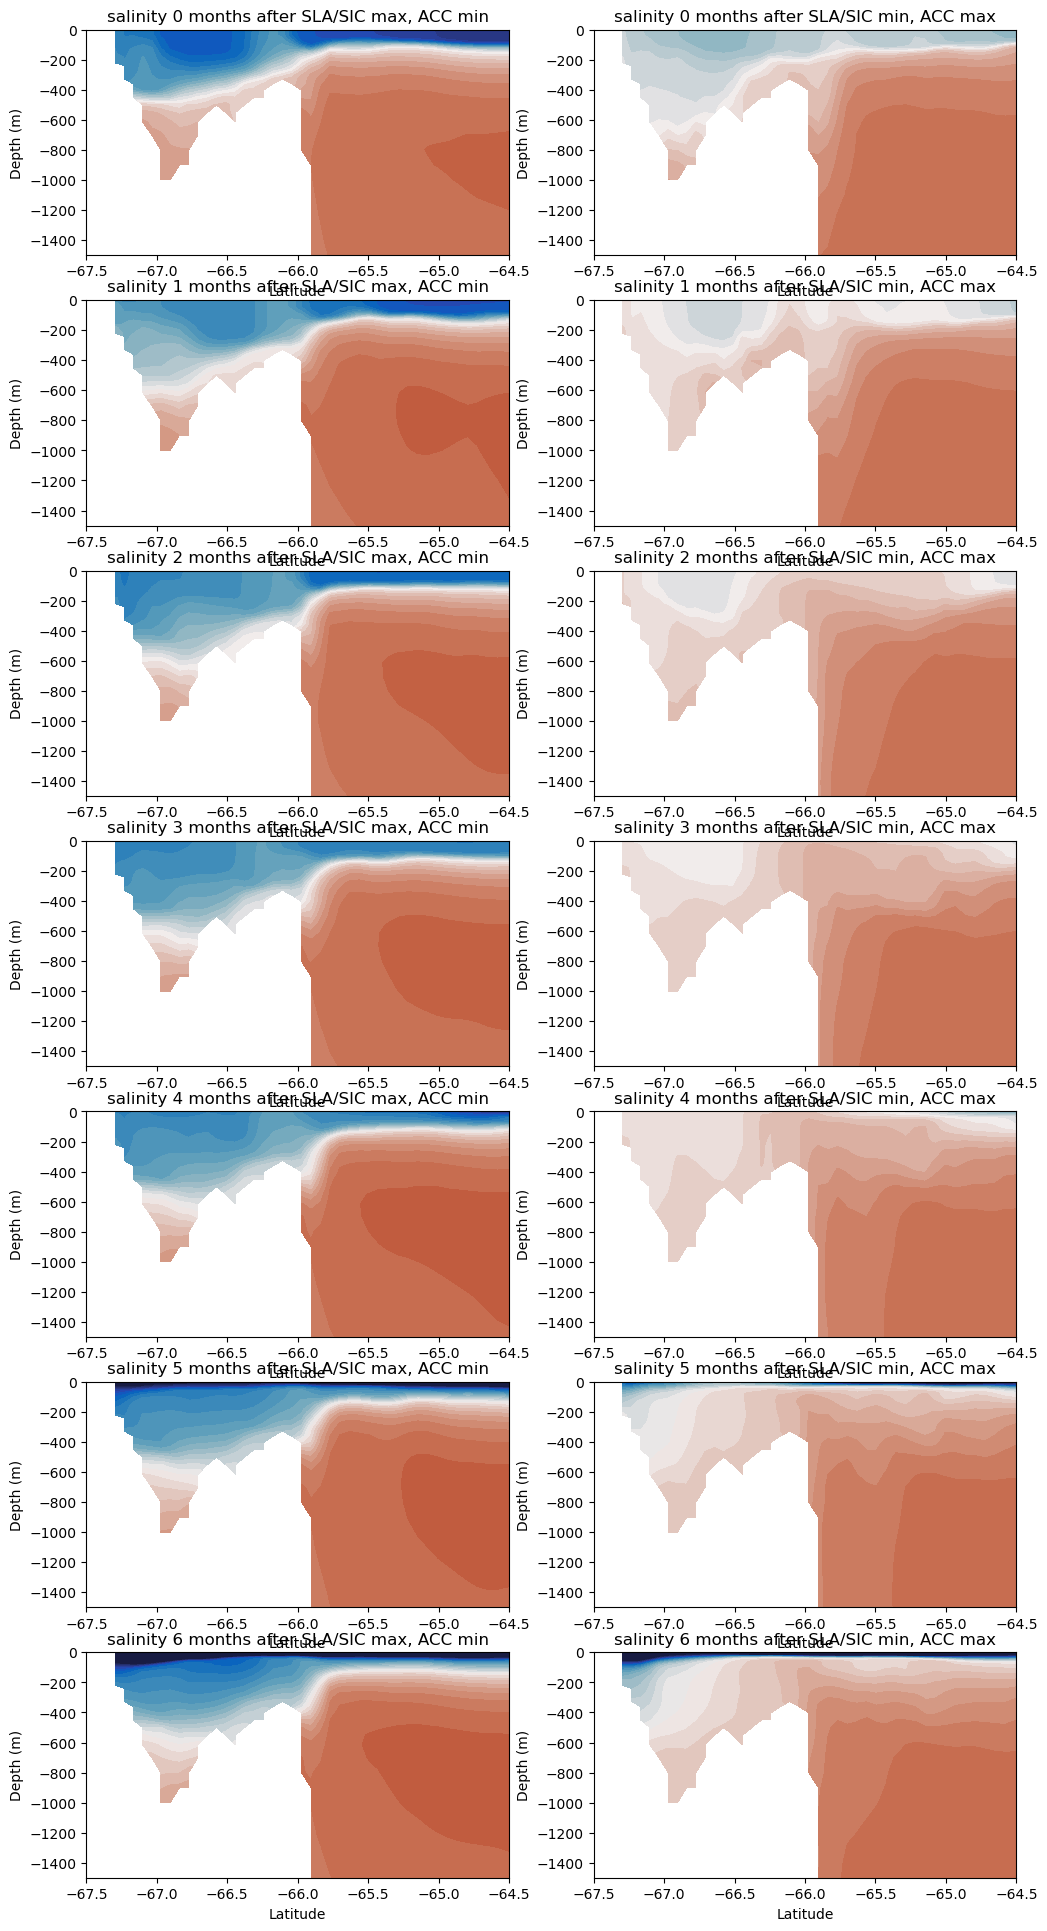

In [28]:
t1 = pd.Timestamp(2013,8,1)
t2 = pd.Timestamp(2020,8,1)

fig,axs = plt.subplots(7,2,figsize=(12,24))
n=1.5
for m in np.arange(7):
    sose145t = ds145.SALT.sel(time = t1+rd(months=m))
    plot_transect(sose145t,axs[m][0],'salinity {} months after SLA/SIC max, ACC min'.format(m),34,35)
    sose145t = ds145.SALT.sel(time = t2+rd(months=m))
    plot_transect(sose145t,axs[m][1],'salinity {} months after SLA/SIC min, ACC max'.format(m),34,35)



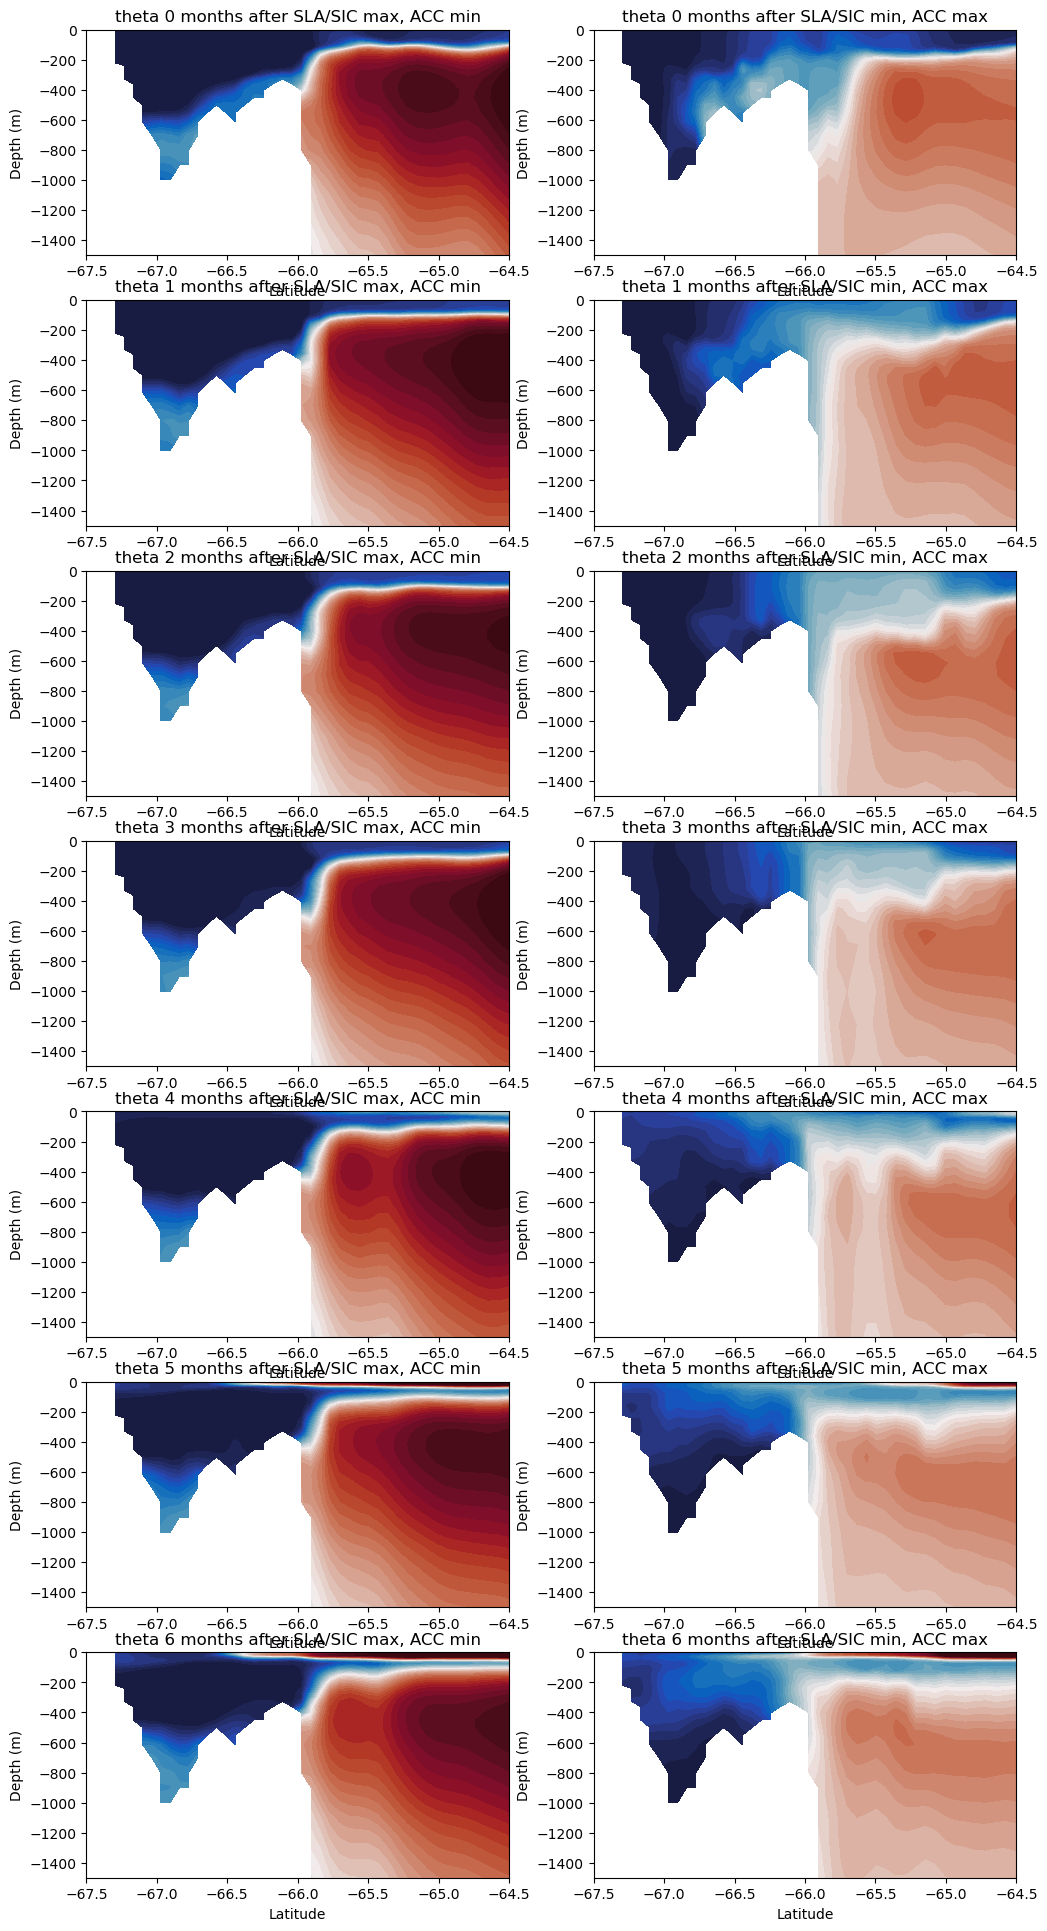

In [29]:
t1 = pd.Timestamp(2013,9,1)
t2 = pd.Timestamp(2020,9,1)

fig,axs = plt.subplots(7,2,figsize=(12,24))
n=1.5
for m in np.arange(7):
    sose145t = ds145.THETA.sel(time = t1+rd(months=m))
    plot_transect(sose145t,axs[m][0],'theta {} months after SLA/SIC max, ACC min'.format(m),-n,n)
    sose145t = ds145.THETA.sel(time = t2+rd(months=m))
    plot_transect(sose145t,axs[m][1],'theta {} months after SLA/SIC min, ACC max'.format(m),-n,n)



In [30]:


sosemin=sa_sose_140.sel(time=tmin,method='nearest')
sosemax=sa_sose_140.sel(time=tmax,method='nearest')

fig,axs = plt.subplots(4,2,figsize=(14,14))

z = -1500

mintxt = '09/2013: high SLA/SIC, weak ACC'
maxtxt = '09/2022: low SLA/SIC, strong ACC'

ax = axs[0]
sosemin.SIarea.plot(ax=ax[0])
ax[0].set_title('SEA ICE AREA ' + mintxt)
ax[0].set_ylim([-0.1,0.2])

sosemax.SIarea.plot(ax=ax[1])
ax[1].set_title('SEA ICE AREA, ' + maxtxt)
ax[1].set_ylim([-0.1,0.2])

def plot_transect(data,ax,title,vmin):
    data.plot(ax=ax,vmin=vmin)
    ax.set_title(title)
    ax.set_ylim([z,0])
    ax.set_xlim([-67.5,-64.5])

ax = axs[1]
plot_transect(sosemin.THETA,ax[0],'THETA, '+mintxt,-0.3)
plot_transect(sosemax.THETA,ax[1],'THETA, '+maxtxt,-0.3)

ax = axs[2]
plot_transect(sosemin.SALT,ax[0],'SALINITY, '+mintxt,-0.08)
plot_transect(sosemax.SALT,ax[1],'SALINITY, '+maxtxt,-0.08)

ax = axs[3]
plot_transect(sosemin.sigma0,ax[0],'SIGMA0, '+mintxt,-0.08)
plot_transect(sosemax.sigma0,ax[1],'SIGMA0, '+maxtxt,-0.08)
plt.tight_layout()


NameError: name 'tmin' is not defined

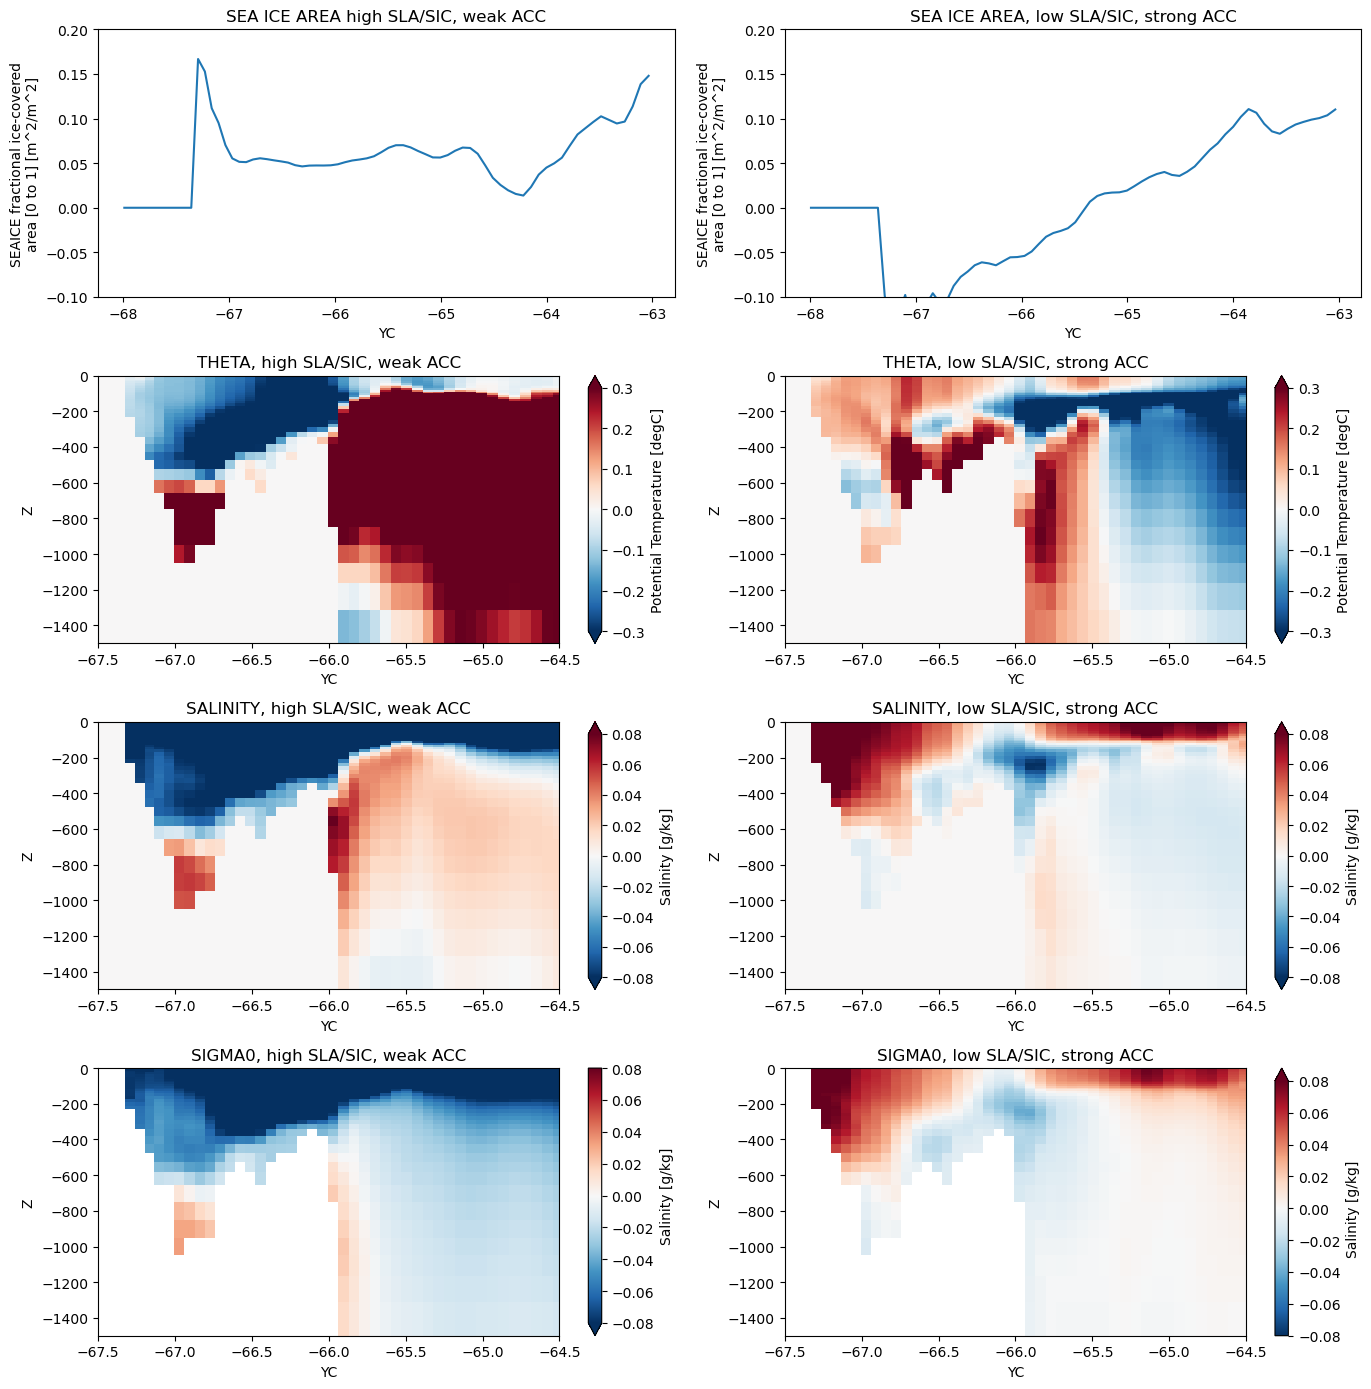

In [ ]:

sosemin=sa_sose_145.sel(time=tmin,method='nearest')
sosemax=sa_sose_145.sel(time=tmax,method='nearest')

fig,axs = plt.subplots(4,2,figsize=(14,14))

z = -1500

mintxt = 'high SLA/SIC, weak ACC'
maxtxt = 'low SLA/SIC, strong ACC'

ax = axs[0]
sosemin.SIarea.plot(ax=ax[0])
ax[0].set_title('SEA ICE AREA ' + mintxt)
ax[0].set_ylim([-0.1,0.2])

sosemax.SIarea.plot(ax=ax[1])
ax[1].set_title('SEA ICE AREA, ' + maxtxt)
ax[1].set_ylim([-0.1,0.2])

def plot_transect(data,ax,title,vmin):
    data.plot(ax=ax,vmin=vmin)
    ax.set_title(title)
    ax.set_ylim([z,0])
    ax.set_xlim([-67.5,-64.5])

ax = axs[1]
plot_transect(sosemin.THETA,ax[0],'THETA, '+mintxt,-0.3)
plot_transect(sosemax.THETA,ax[1],'THETA, '+maxtxt,-0.3)

ax = axs[2]
plot_transect(sosemin.SALT,ax[0],'SALINITY, '+mintxt,-0.08)
plot_transect(sosemax.SALT,ax[1],'SALINITY, '+maxtxt,-0.08)

ax = axs[3]
plot_transect(sosemin.sigma0,ax[0],'SIGMA0, '+mintxt,-0.08)
plot_transect(sosemax.sigma0,ax[1],'SIGMA0, '+maxtxt,-0.08)
plt.tight_layout()


In [ ]:
s = 'autumn'
lag=0
frac=0.1

topboo, botboo, top, bot = fns.get_topbot(sa_asc,frac)
fns.run_for_idx(sa_asc,frac,sa_sla,sa_geos,'SLA',extent_ac,lag=lag,ylim_idx=10,ylim1=6)
fig,axs = plt.subplots(4,2,figsize=(14,14))

z = -1500
tops = top(sa_sose_145,lag)#ssn_sose[s],lag)
bots = bot(sa_sose_145,lag)#ssn_sose[s],lag)


ax = axs[0]
tops.SIarea.plot(ax=ax[0])
ax[0].set_title('SEA ICE AREA, high ASC')
ax[0].set_ylim([-0.1,0.2])

bots.SIarea.plot(ax=ax[1])
ax[1].set_title('SEA ICE AREA, low ASC')
ax[1].set_ylim([-0.1,0.2])

def plot_transect(data,ax,title,vmin):
    data.plot(ax=ax,vmin=vmin)
    ax.set_title(title)
    ax.set_ylim([z,0])
    ax.set_xlim([-67.5,-64.5])

ax = axs[1]
plot_transect(tops.THETA,ax[0],'THETA, high ASC',-0.3)
plot_transect(bots.THETA,ax[1],'THETA, low ASC',-0.3)

ax = axs[2]
plot_transect(tops.SALT,ax[0],'SALINITY, high ASC',-0.08)
plot_transect(bots.SALT,ax[1],'SALINITY, low ASC',-0.08)

ax = axs[3]
plot_transect(tops.sigma0,ax[0],'SIGMA0, high ASC',-0.08)
plot_transect(bots.sigma0,ax[1],'SIGMA0, low ASC',-0.08)
plt.tight_layout()


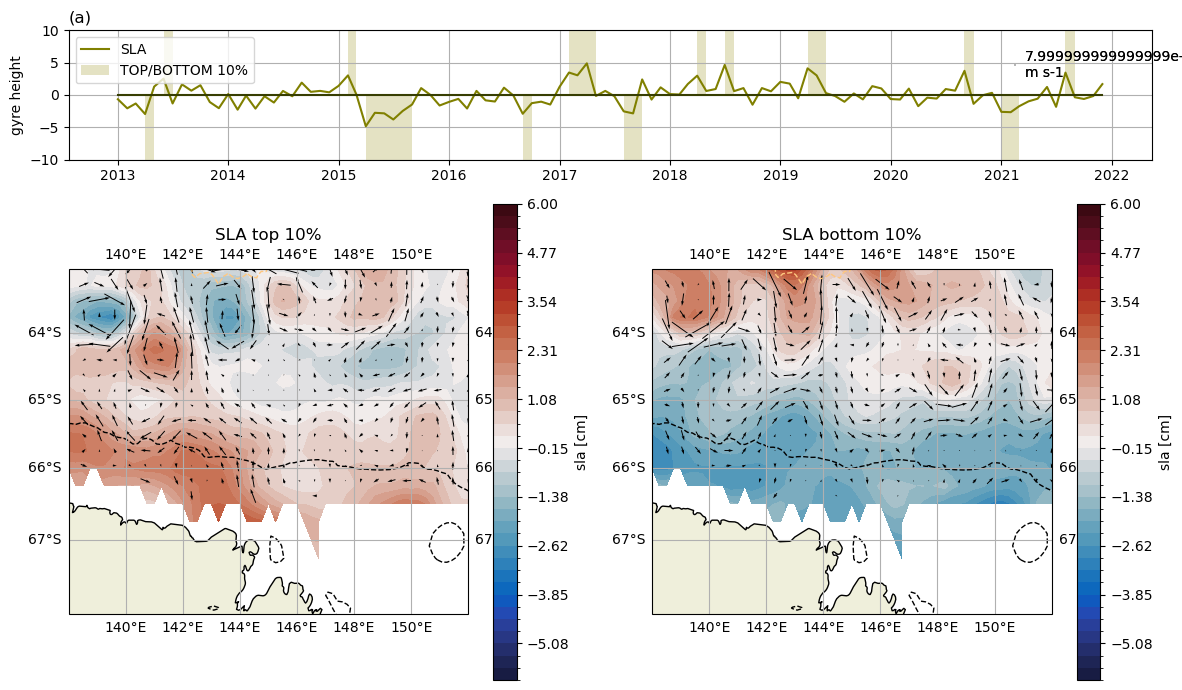

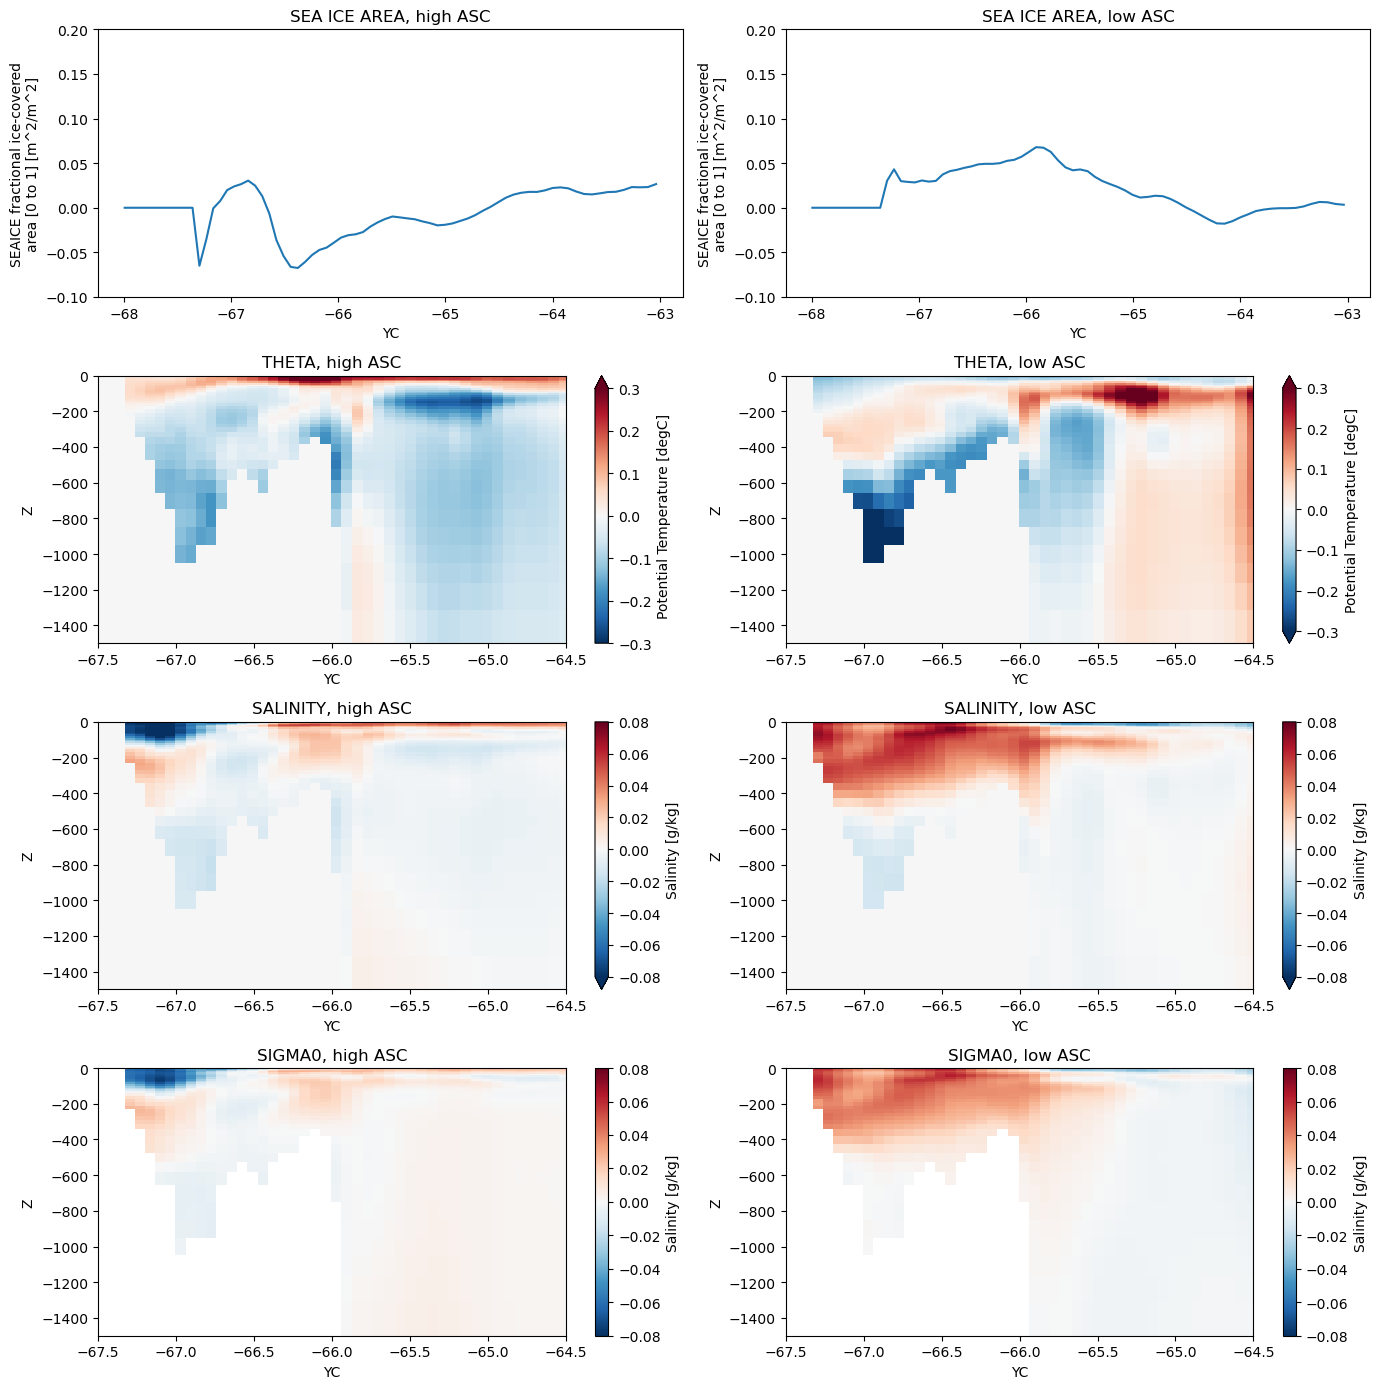

In [ ]:
s = 'autumn'
lag=0
frac=0.1

topboo, botboo, top, bot = fns.get_topbot(sa_asc,frac)
fns.run_for_idx(sa_asc,frac,sa_sla,sa_geos,'SLA',extent_ac,lag=lag,ylim_idx=10,ylim1=6)
fig,axs = plt.subplots(4,2,figsize=(14,14))

z = -1500
tops = top(sa_sose_145,lag)#ssn_sose[s],lag)
bots = bot(sa_sose_145,lag)#ssn_sose[s],lag)


ax = axs[0]
tops.SIarea.plot(ax=ax[0])
ax[0].set_title('SEA ICE AREA, high ASC')
ax[0].set_ylim([-0.1,0.2])

bots.SIarea.plot(ax=ax[1])
ax[1].set_title('SEA ICE AREA, low ASC')
ax[1].set_ylim([-0.1,0.2])

def plot_transect(data,ax,title,vmin):
    data.plot(ax=ax,vmin=vmin)
    ax.set_title(title)
    ax.set_ylim([z,0])
    ax.set_xlim([-67.5,-64.5])

ax = axs[1]
plot_transect(tops.THETA,ax[0],'THETA, high ASC',-0.3)
plot_transect(bots.THETA,ax[1],'THETA, low ASC',-0.3)

ax = axs[2]
plot_transect(tops.SALT,ax[0],'SALINITY, high ASC',-0.08)
plot_transect(bots.SALT,ax[1],'SALINITY, low ASC',-0.08)

ax = axs[3]
plot_transect(tops.sigma0,ax[0],'SIGMA0, high ASC',-0.08)
plot_transect(bots.sigma0,ax[1],'SIGMA0, low ASC',-0.08)
plt.tight_layout()


In [ ]:
# mean on shelf
shelf140 = sa_sose_140.where(sa_sose_140.Depth < 1000,drop=True)
shelf145 = sa_sose_145.where(sa_sose_145.Depth < 1000,drop=True)

In [ ]:
shelf140.to_netcdf('sose_shelf_140.nc')
shelf145.to_netcdf('sose_shelf_145.nc')

(-2500.0, 0.0)

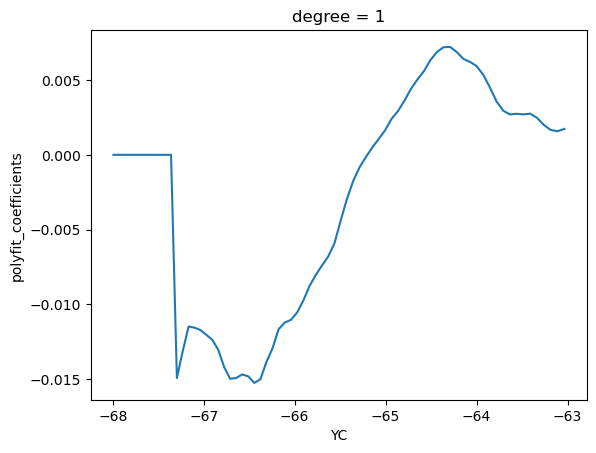

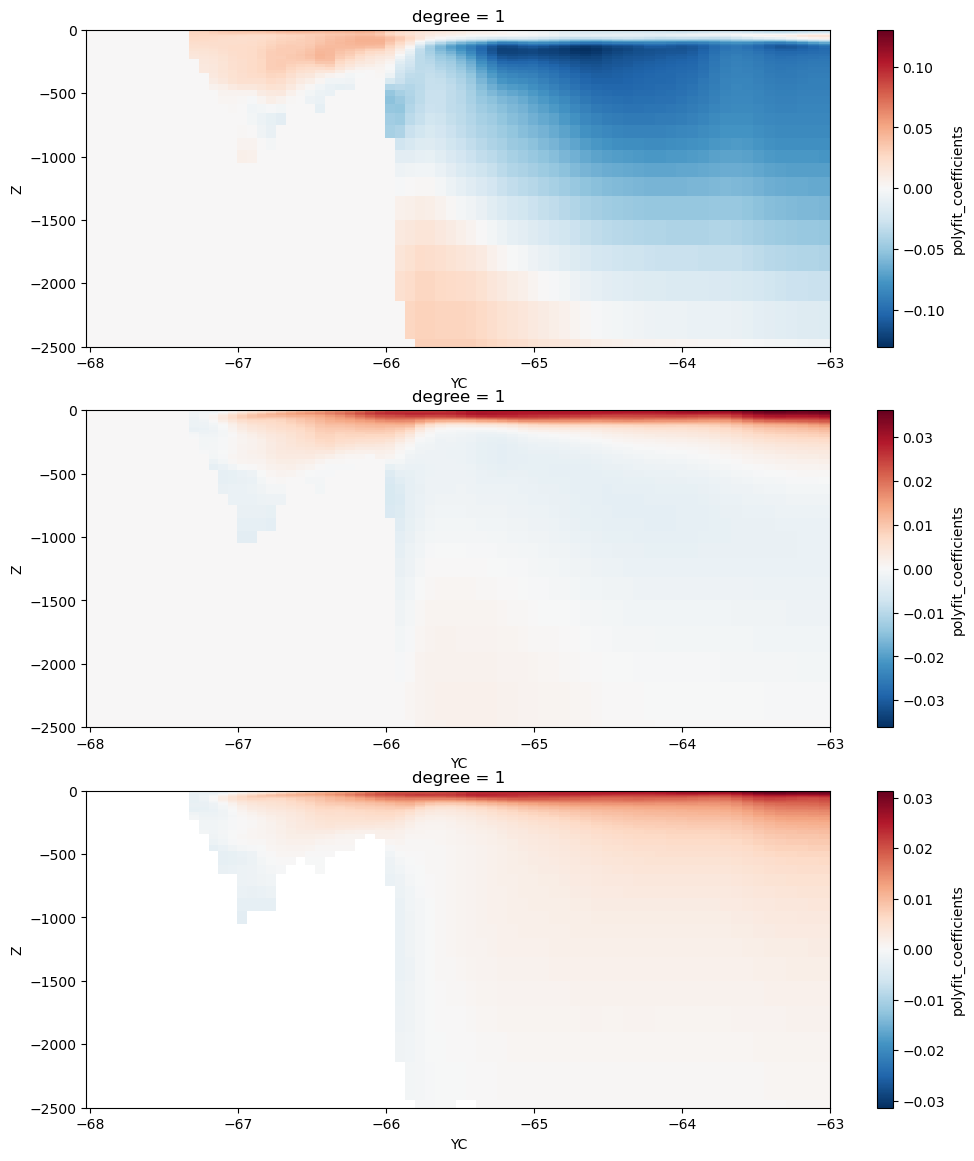

In [ ]:
theta_trend = fns.get_trend(ds145.THETA)
psal_trend = fns.get_trend(ds145.SALT)
sigma_trend = fns.get_trend(ds145.sigma0)
ice_trend = fns.get_trend(ds145.SIarea)

ice_trend.plot()
fig,axs = plt.subplots(3,1,figsize=(12,14))

ax=axs[0]
theta_trend.plot(x='YC',y='Z',ax=ax)
ax.set_ylim([-2500,0])

ax=axs[1]
psal_trend.plot(x='YC',y='Z',ax=ax)
ax.set_ylim([-2500,0])

ax=axs[2]
sigma_trend.plot(x='YC',y='Z',ax=ax)
ax.set_ylim([-2500,0])

In [ ]:
def get_xht(ds):
    ds['thetav'] = ds.THETA.interp({'YC':ds.YG})
    ds['thetavvel'] = ds.thetav * ds.VVEL
    ds['xht'] = -ds.thetavvel.integrate('Z')

xhtl = 'Northward Cross-Shelf Heat Transport'

In [ ]:
get_xht(ds145)
get_xht(ds140)
get_xht(dsseg)

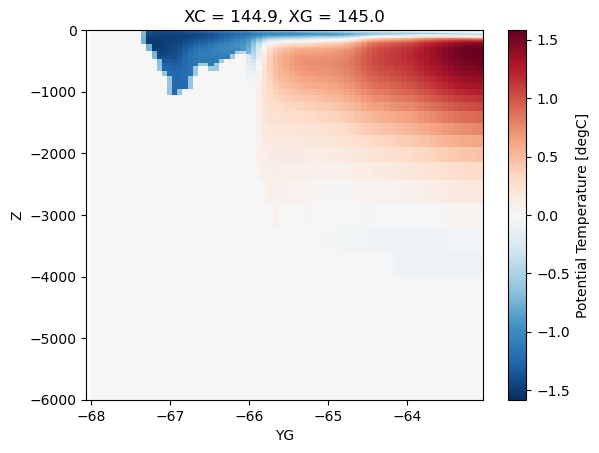

In [ ]:
ds145.thetav.mean('time').plot()


In [ ]:
dsseg.UVEL

<xarray.DataArray 'UVEL' (time: 132, Z: 52, YC: 15, XG: 73)> Size: 30MB
array([[[[-0.11351591, -0.11364583, -0.11296034, ...,  0.06365241,
           0.05605385,  0.04845608],
         [-0.11491787, -0.11417192, -0.1139613 , ...,  0.09973124,
           0.09602018,  0.08896291],
         [-0.11834333, -0.11746937, -0.11743579, ...,  0.12206987,
           0.12441859,  0.11733854],
         ...,
         [ 0.0398788 ,  0.04364948,  0.04595809, ...,  0.13930182,
           0.12694946,  0.11607305],
         [ 0.01643017,  0.01536007,  0.01059491, ...,  0.16416056,
           0.14661138,  0.13097905],
         [-0.01221673, -0.01309277, -0.01387892, ...,  0.19499932,
           0.17771335,  0.15916441]],

        [[-0.05202721, -0.05211634, -0.05117763, ...,  0.09590435,
           0.08733595,  0.07915246],
         [-0.05184802, -0.0508084 , -0.05058866, ...,  0.13302721,
           0.12842236,  0.12037734],
         [-0.05463448, -0.05352984, -0.05365966, ...,  0.1549296 ,
           0.15691453,  0.14893852],
...
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ]],

        [[ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         ...,
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ]]]],
      shape=(132, 52, 15, 73), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2013-01-01 2013-02-01 ... 2023-12-01
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * YC       (YC) float64 120B -65.97 -65.91 -65.84 ... -65.15 -65.08 -65.01
  * XG       (XG) float64 584B 138.0 138.2 138.3 138.5 ... 149.7 149.8 150.0
    dxC      (YC, XG) float64 9kB 7.545e+03 7.545e+03 ... 7.829e+03 7.829e+03
    dyG      (YC, XG) float64 9kB 7.545e+03 7.545e+03 ... 7.829e+03 7.829e+03
    rAw      (YC, XG) float64 9kB 5.692e+07 5.692e+07 ... 6.13e+07 6.13e+07
    drF      (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
    hFacW    (Z, YC, XG) float64 456kB 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
Attributes:
    standard_name:  UVEL
    long_name:      Zonal Component of Velocity (m/s)
    units:          m/s
    mate:           VVEL

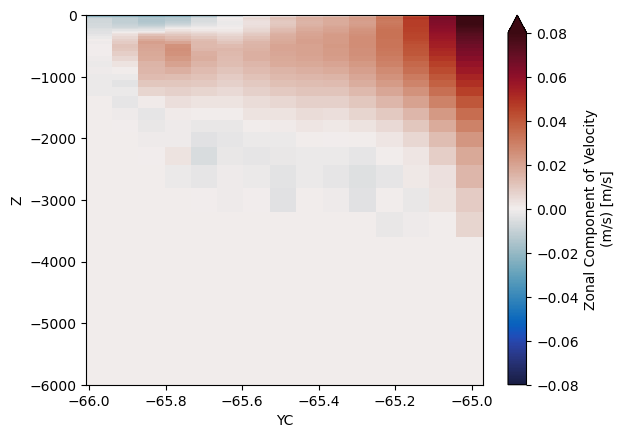

In [ ]:
dsseg.UVEL.sel(time=slice(pd.Timestamp(2014,1,1),pd.Timestamp(2014,12,1))).mean('time').mean('XG').plot(cmap=cmocean.cm.balance,vmin=-0.08)

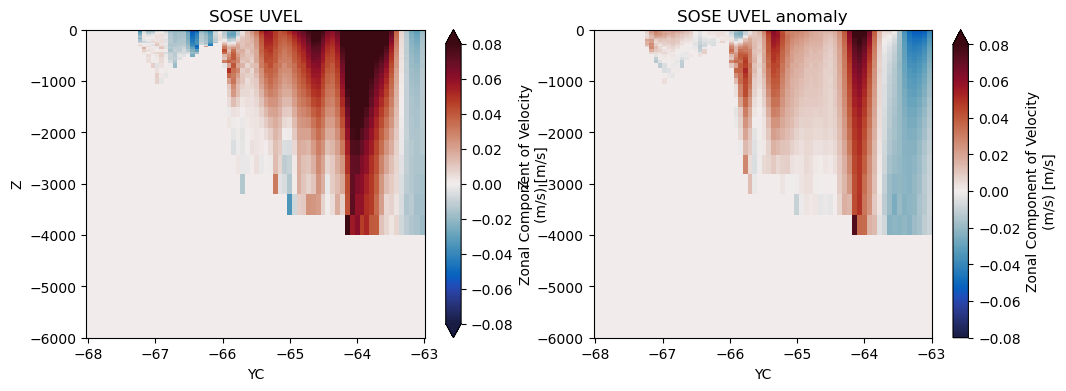

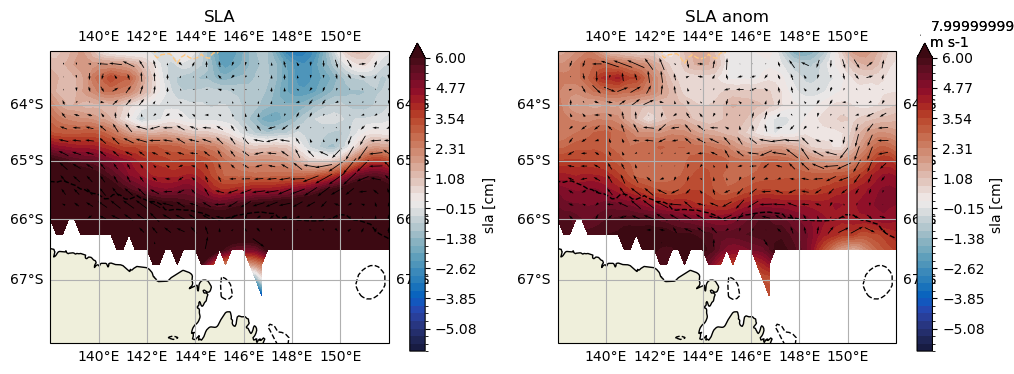

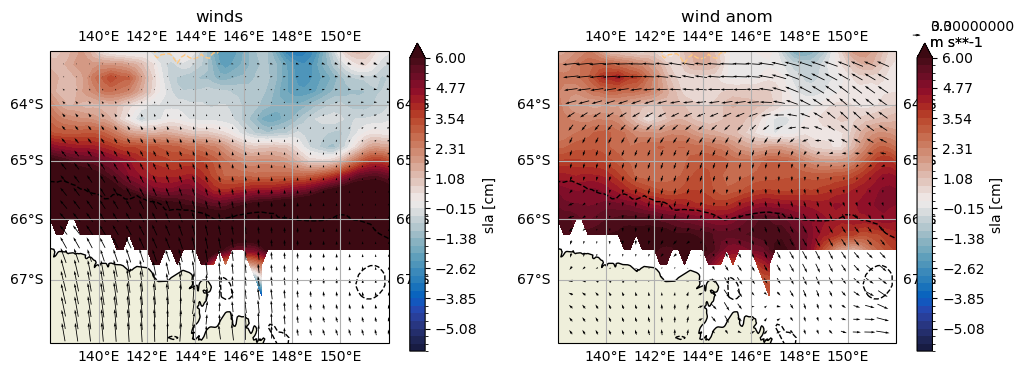

In [ ]:
t1test=pd.Timestamp(2014,1,1)
t2test=pd.Timestamp(2014,12,1)

tcut = lambda ds: ds.sel(time=slice(t1test,t2test)).mean('time')


fig,ax = plt.subplots(1,2,figsize=(12,4))
tcut(ds145.UVEL).plot(ax=ax[0],cmap=cmocean.cm.balance,vmin=-0.08)
tcut(sa_sose_145.UVEL).plot(ax=ax[1],cmap=cmocean.cm.balance,vmin=-0.08)
ax[0].set_title('SOSE UVEL')
ax[1].set_title('SOSE UVEL anomaly')

fig,ax = plt.subplots(1,2,figsize=(12,4),subplot_kw={'projection':ccrs.Mercator()})
fns.plotc(ax[0],tcut(sla),'SLA',  extent_ac,-6,6,cmap=cmocean.cm.balance,vector=tcut(geos))
fns.plotc(ax[1],tcut(sa_sla),'SLA anom',extent_ac,-6,6,vector=tcut(sa_geos))

fig,ax = plt.subplots(1,2,figsize=(12,4),subplot_kw={'projection':ccrs.Mercator()})
fns.plotc(ax[0],tcut(sla),'winds',  extent_ac,-6,6,cmap=cmocean.cm.balance,vector=tcut(winds))
fns.plotc(ax[1],tcut(sa_sla),'wind anom',extent_ac,-6,6,vector=tcut(sa_winds))



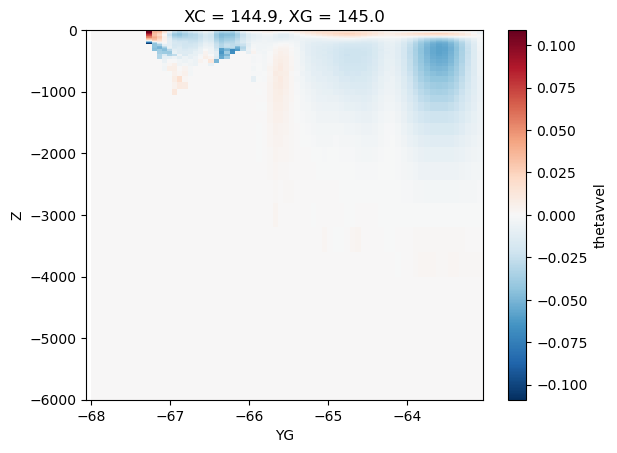

In [ ]:
ds145.thetavvel.mean('time').plot()


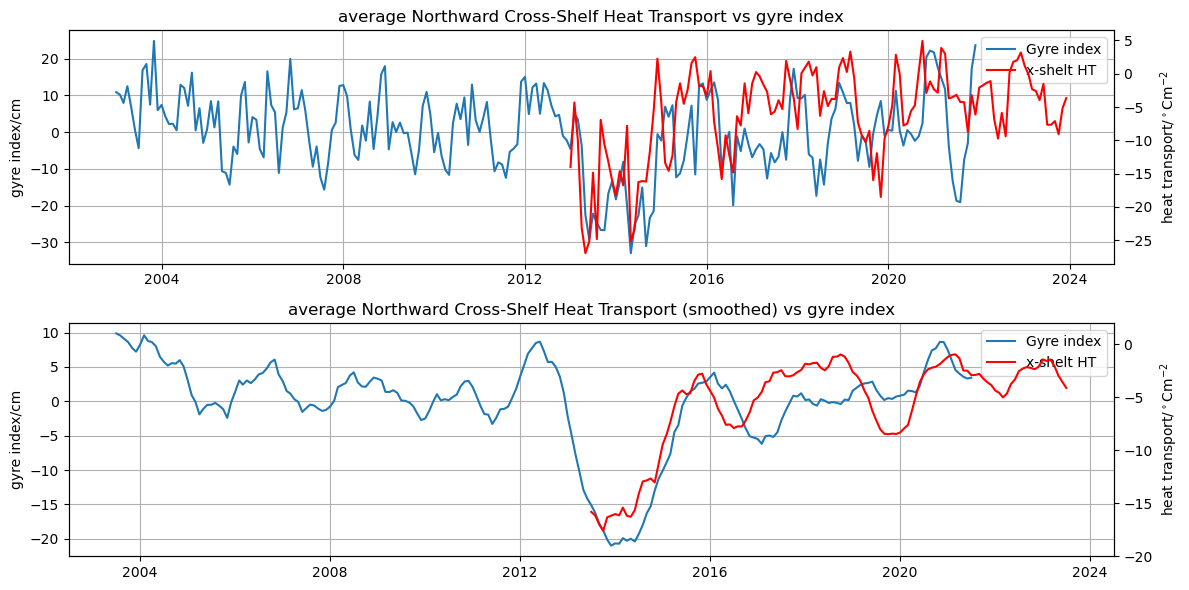

In [ ]:
#repeat for l
dsl = ds145.sel(YG=slice(-67,-65)).mean('YG')#,method='nearest')

fig,axs = plt.subplots(2,1,figsize=(12,6))
ax=axs[0]
ax2=ax.twinx()
l1 = ax.plot(gyre_index.time,gyre_index)
l2 = ax2.plot(dsl.time,dsl.xht,c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelt HT'])
ax.grid()
ax2.set_ylabel(r'heat transport/$^\circ$Cm$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title('average ' + xhtl + ' vs gyre index')

ax=axs[1]
ax2=ax.twinx()
l1=ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
l2=ax2.plot(dsl.time,dsl.xht.rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelt HT'])
ax.grid()
ax2.set_ylabel(r'heat transport/$^\circ$Cm$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title('average ' + xhtl + ' (smoothed) vs gyre index')
ax2.set_ylim([-20,2])

plt.tight_layout()



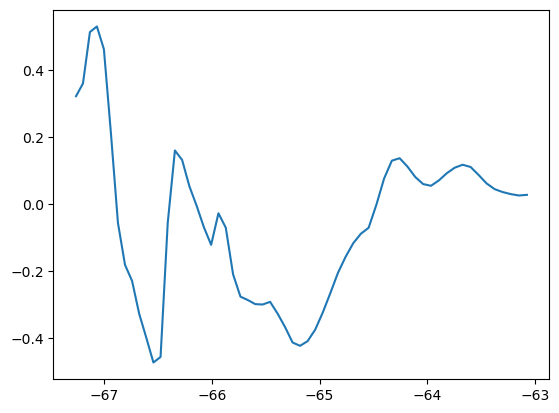

In [ ]:
plt.plot(ds145.YG,corr)

In [ ]:
corr=[]
maxl=0
gic = gyre_index.sel(time=slice(ds145.xht.time[0],gyre_index.time[-1]))
dsc = ds145.sel(time=slice(ds145.xht.time[0],gyre_index.time[-1]))
for yg in dsc.YG:
    dsyg = dsc.sel(YG=yg)
    xhtyg = dsyg.thetavvel.integrate('Z')
    cc = xr.corr(gic,xhtyg)
    corr.append(cc.item())
    

/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


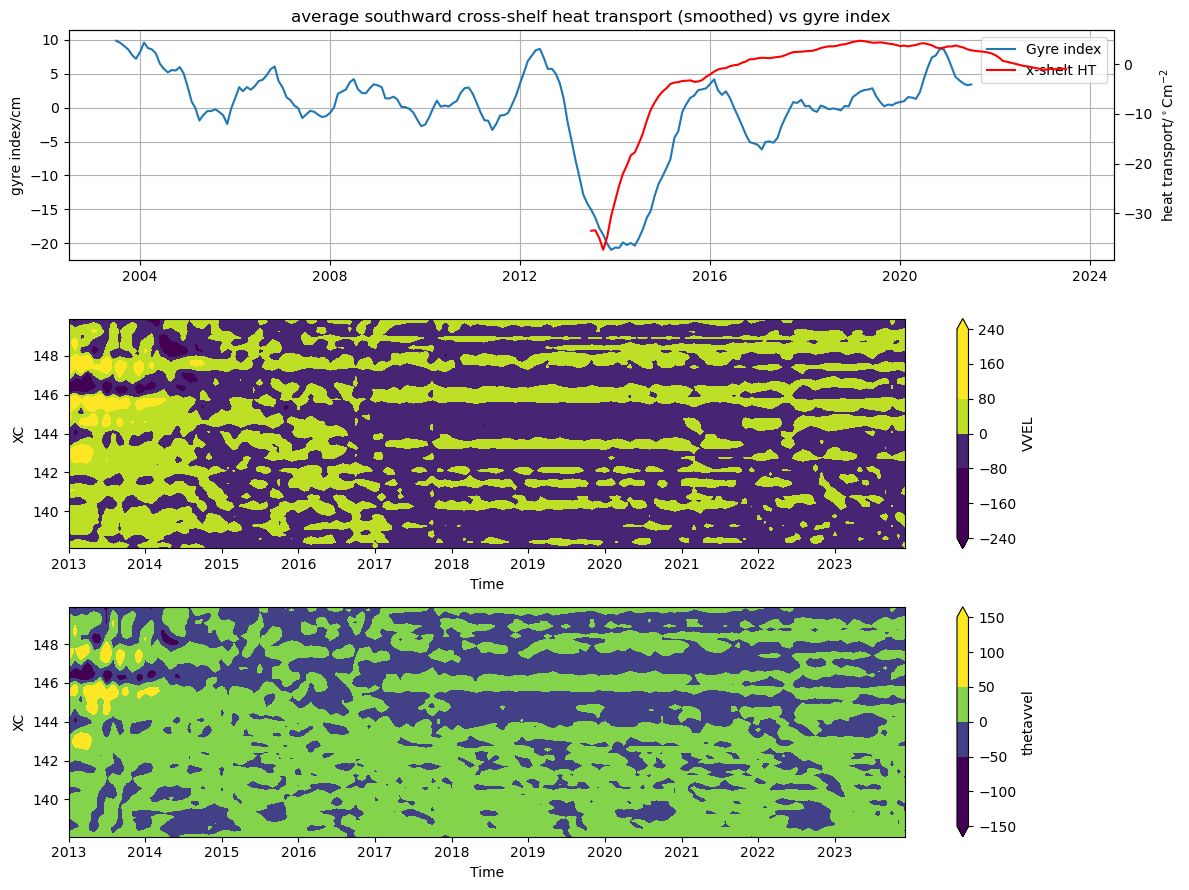

In [ ]:
dsm = dsseg.mean('YG')


fig,axs = plt.subplots(3,1,figsize=(12,9))
ax=axs[0]
ax2=ax.twinx()
l1=ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
l2=ax2.plot(dsm.time,dsm.sel(XC=slice(144,146)).mean('XC').xht.rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelt HT'])
ax.grid()
ax2.set_ylabel(r'heat transport/$^\circ$Cm$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title('average southward cross-shelf heat transport (smoothed) vs gyre index')

ax=axs[1]
dsm.VVEL.integrate('Z').plot(ax=ax,x='time',y='XC',vmin=-50,vmax=50)

ax=axs[2]
dsm.thetavvel.integrate('Z').plot(ax=ax,x='time',y='XC',vmin=-40,vmax=40)


plt.tight_layout()

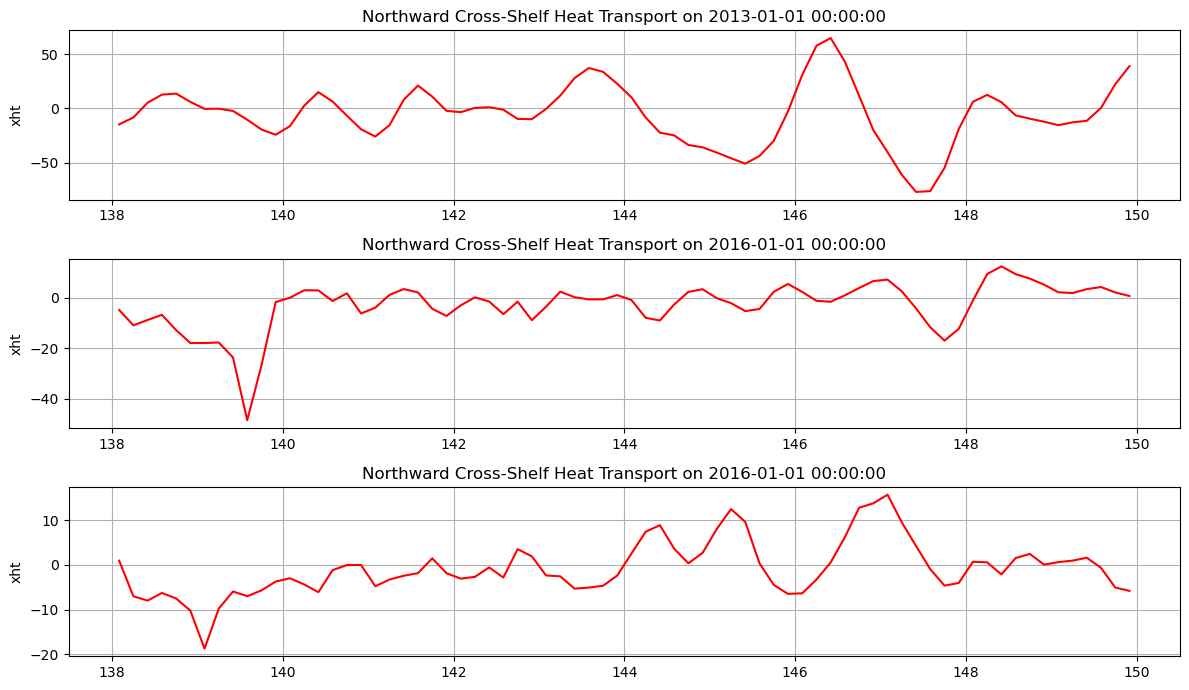

In [ ]:
dsm = dsseg.mean('YG')


fig,axs = plt.subplots(3,1,figsize=(12,7))

t1 = pd.Timestamp(2013,1,1)
t2 = pd.Timestamp(2016,1,1)
t3 = pd.Timestamp(2020,1,1)

ax=axs[0]
ax.plot(dsm.XC,dsm.sel(time=t1).xht,c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t1))

ax=axs[1]
ax.plot(dsm.XC,dsm.sel(time=t2).xht,c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t2))

ax=axs[2]
ax.plot(dsm.XC,dsm.sel(time=t3).xht,c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t2))

plt.tight_layout()


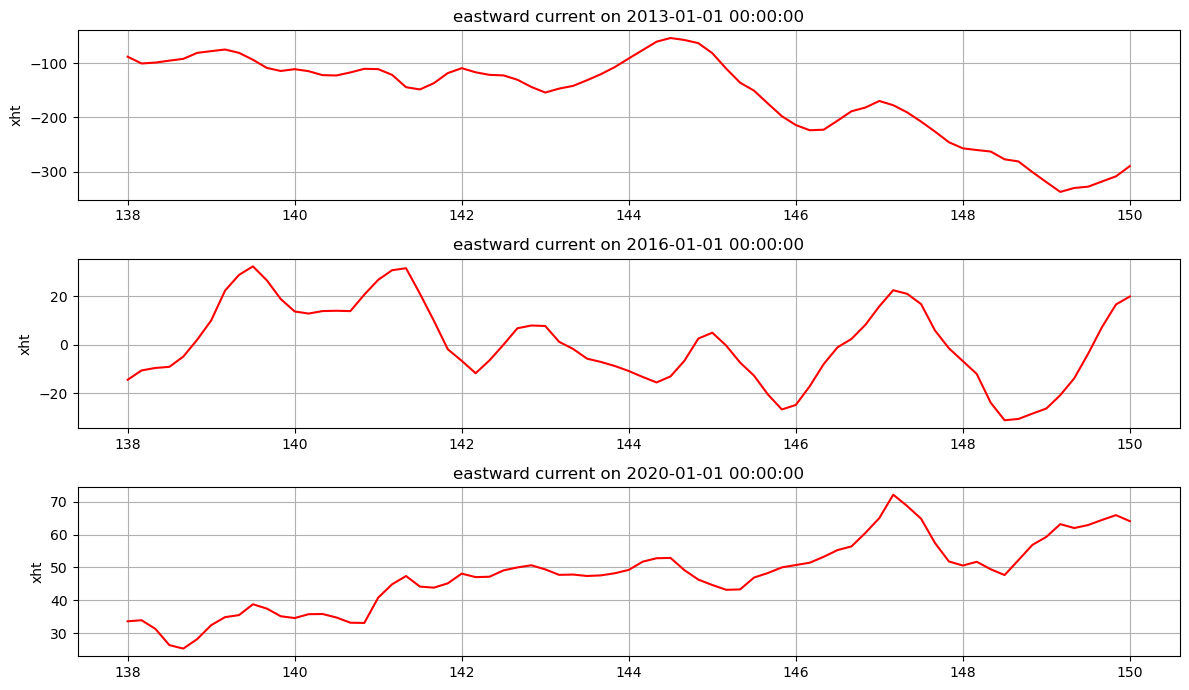

In [ ]:
dsm = dsseg.mean('YC')


fig,axs = plt.subplots(3,1,figsize=(12,7))

t1 = pd.Timestamp(2013,1,1)
t2 = pd.Timestamp(2016,1,1)
t3 = pd.Timestamp(2020,1,1)

xhtl = 'eastward current'
ax=axs[0]
ax.plot(dsm.XG,dsm.sel(time=t1).UVEL.integrate('Z'),c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t1))

ax=axs[1]
ax.plot(dsm.XG,dsm.sel(time=t2).UVEL.integrate('Z'),c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t2))

ax=axs[2]
ax.plot(dsm.XG,dsm.sel(time=t3).UVEL.integrate('Z'),c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t3))

plt.tight_layout()

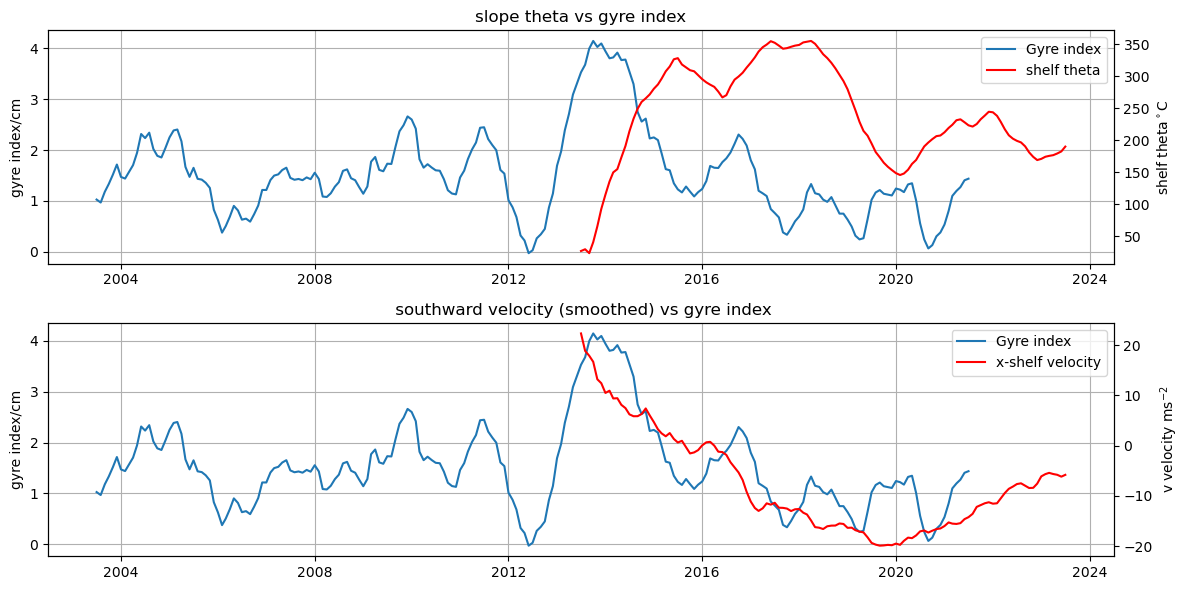

In [ ]:
fig,axs = plt.subplots(2,1,figsize=(12,6))
ax=axs[0]
l1 = ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
ax2=ax.twinx()
l2 = ax2.plot(ds.time,ds.thetav.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','shelf theta'])
ax.grid()
ax2.set_ylabel(r'shelf theta$^\circ$C')
ax.set_ylabel('gyre index/cm')
ax.set_title('slope theta vs gyre index')

ax=axs[1]
ax2=ax.twinx()
l1=ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
l2=ax2.plot(ds.time,ds.VVEL.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelf velocity'])
ax.grid()
ax2.set_ylabel(r'v velocity ms$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title(' southward velocity (smoothed) vs gyre index')

plt.tight_layout()

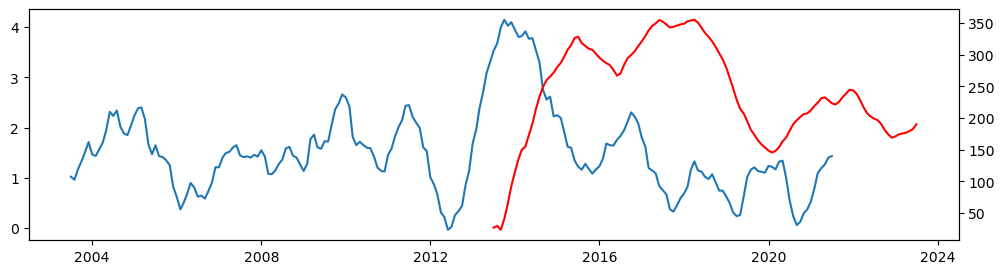

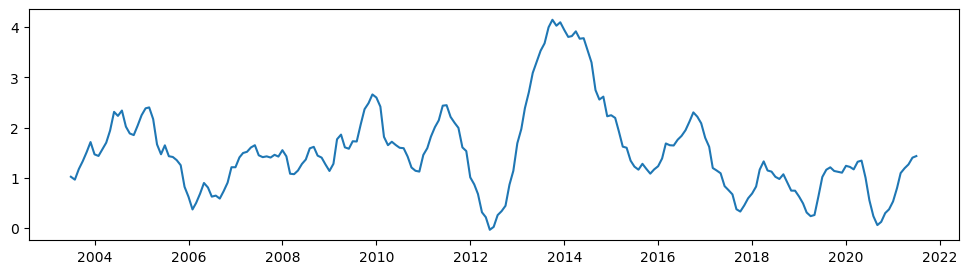

In [ ]:

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
ax.twinx().plot(ds.time,ds.thetav.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())


In [ ]:
s_sigma = fns.season_split(ds.sigma0)
s_theta = fns.season_split(ds.THETA)
s_salty = fns.season_split(ds.SALT)


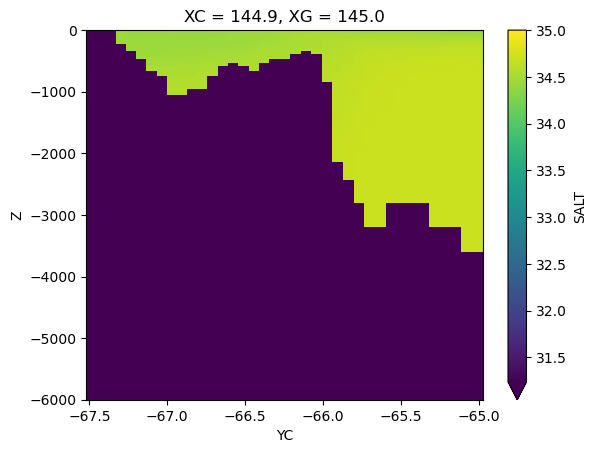

In [ ]:
s_salty['spring'].mean('time').plot(vmin=35)

In [ ]:
dss = fns.season_split(ds.sigma0)

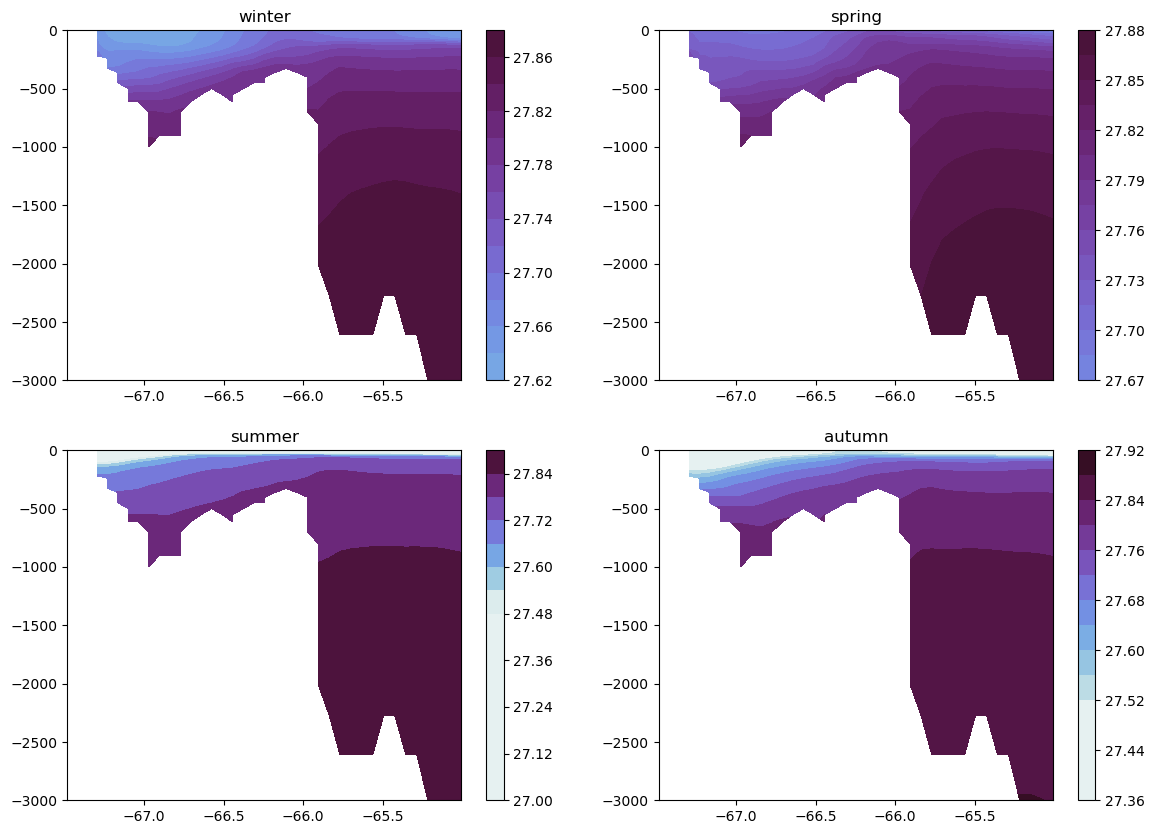

In [ ]:
fig,axs = plt.subplots(2,2,figsize=(14,10))

def plotit(ax,s):
    im=ax.contourf(ds.YC,ds.Z,dss[s].mean('time'),vmax=27.9,vmin=27.5,levels=15,cmap=cmocean.cm.dense)
    ax.set_ylim([-3000,0])
    ax.set_title(s)
    plt.colorbar(im)

plotit(axs[0][0],'winter')
plotit(axs[0][1],'spring')
plotit(axs[1][0],'summer')
plotit(axs[1][1],'autumn')



In [ ]:
fig,axs = plt.subplots(2,2,figsize=(14,10))
dss = fns.season_split(ds.THETA)
def plotit(ax,s):
    im=ax.contourf(ds.YC,ds.Z,dss[s].mean('time'),vmax=1,vmin=-1.5,levels=15,cmap=cmocean.cm.dense)
    ax.set_ylim([-3000,0])
    ax.set_title(s)
    plt.colorbar(im)

plotit(axs[0][0],'winter')
plotit(axs[0][1],'spring')
plotit(axs[1][0],'summer')
plotit(axs[1][1],'autumn')

In [ ]:
#LABEL water masstypes
ds['wmt'] = ds.sigma0 * np.nan

In [ ]:
ds['wmt'].where((ds.sigma0 > 27.7) & ,'mCDW')